In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.applications import InceptionV3
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

train_dir = '/content/drive/MyDrive/train'
validation_dir = '/content/drive/MyDrive/validation'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=True
)
validation_generator = validation_datagen.flow_from_directory(
    validation_dir, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:-50]:
    layer.trainable = False
for layer in base_model.layers[-50:]:
    layer.trainable = True

feature_extractor = models.Model(inputs=base_model.input, outputs=base_model.output)

X_train_features, y_train_labels = [], []
for i, (images, labels) in enumerate(train_generator):
    features = feature_extractor.predict(images, verbose=0)
    X_train_features.append(features)
    y_train_labels.append(labels)
    if i >= len(train_generator) - 1:
        break

X_train_features = np.vstack(X_train_features)
y_train_labels = np.hstack(y_train_labels)

X_flat = X_train_features.reshape(X_train_features.shape[0], -1)
smote = SMOTE(random_state=42)
X_resampled_flat, y_resampled = smote.fit_resample(X_flat, y_train_labels)

scaler = StandardScaler()
X_resampled_flat = scaler.fit_transform(X_resampled_flat)
X_resampled = X_resampled_flat.reshape(-1, 5, 5, 2048)

X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

model = models.Sequential([
    layers.Input(shape=(5, 5, 2048)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

loss_fn = BinaryCrossentropy()
model.compile(optimizer=AdamW(learning_rate=2e-5), loss=loss_fn, metrics=['accuracy'])

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint("best_model_inceptionv3.keras", monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32").flatten()
print("\nClassification Report:\n", classification_report(y_val, y_pred_classes))

Found 1246 images belonging to 2 classes.
Found 309 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/150
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5694 - loss: 0.7646
Epoch 1: val_accuracy improved from -inf to 0.72148, saving model to best_model_inceptionv3.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.5711 - loss: 0.7629 - val_accuracy: 0.7215 - val_loss: 0.5722 - learning_rate: 2.0000e-05
Epoch 2/150
36/38 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6452 - loss: 0.6492
Epoch 2: val_accuracy improved from 0.72148 to 0.76846, saving model to best_model_inceptionv3.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.6471 - loss: 0.6481 - val_accuracy: 0.7685 - val_loss: 0.5034 - learning_rate: 2.0000e-05
Epoch 3/150
37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7025 - loss: 0.6025
Epoch 3: val_accuracy improved from 0.76846 to 0.78523, saving model to best_model_inceptionv3.keras
38/38 ━━━━━━━━━━━━━━

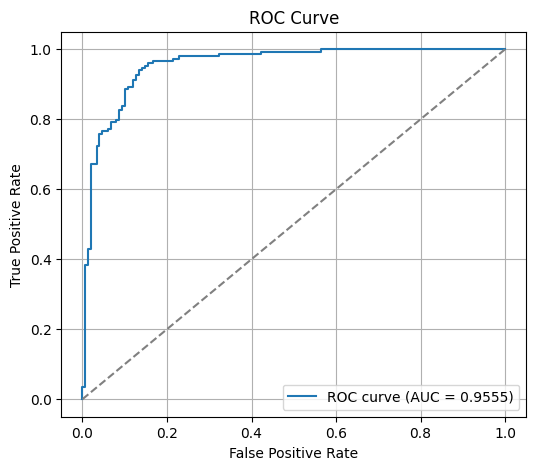

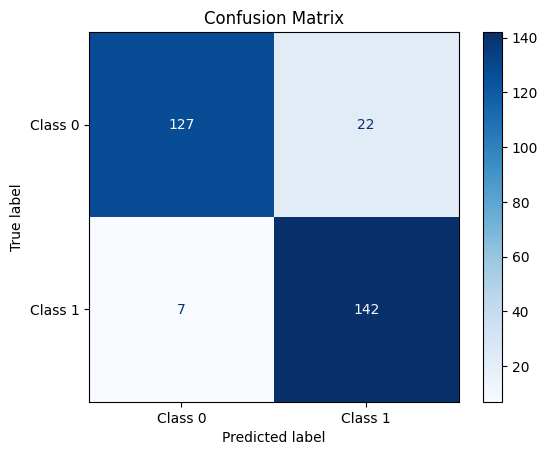

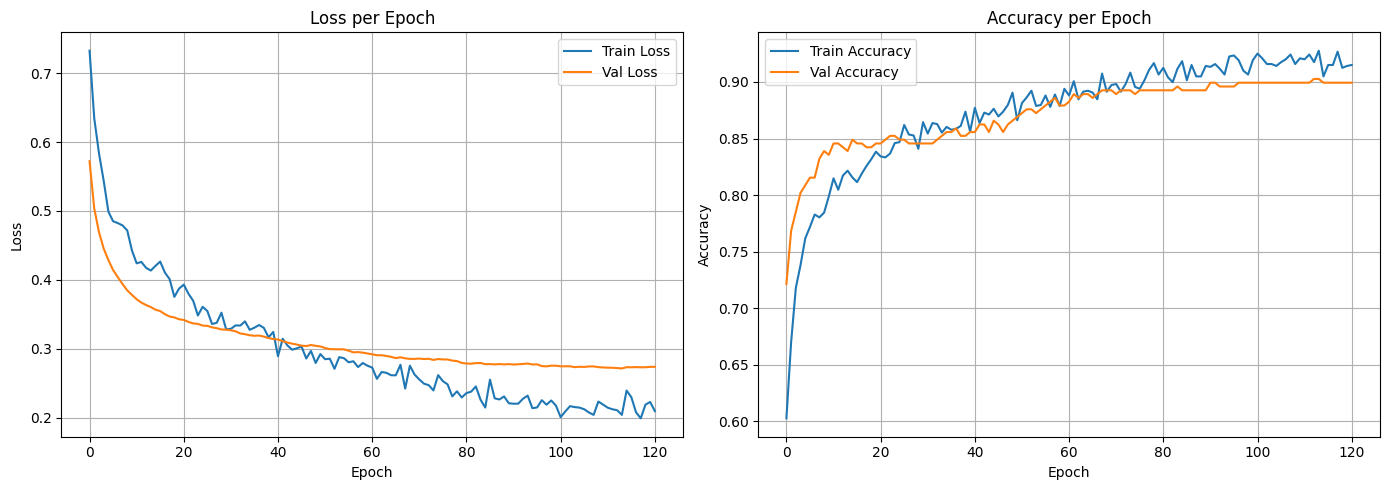

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

fpr, tpr, thresholds = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

cm = confusion_matrix(y_val, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Model: "Image_Only_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 5, 5, 2048)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,051,649 (4.01 MB)

 Trainable params: 1,050,625 (4.01 MB)

 Non-trainable params: 1,024 (4.00 KB)

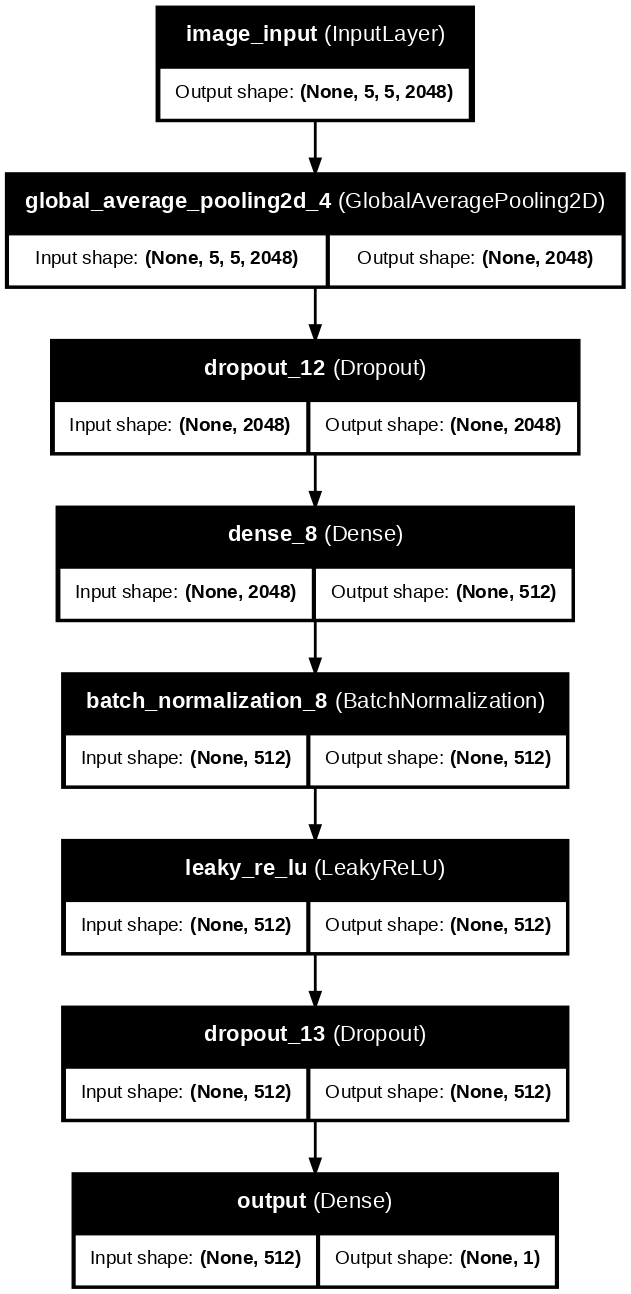

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model

image_input = Input(shape=(5, 5, 2048), name='image_input')
x1 = layers.GlobalAveragePooling2D()(image_input)
x1 = layers.Dropout(0.3)(x1)
text_input = Input(shape=(4,), name='text_input')
x2 = layers.Dense(64, activation='relu')(text_input)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.3)(x2)
merged = layers.Concatenate()([x1, x2])
x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(4, activation='softmax', name='output')(x)

fusion_model = Model(inputs=[image_input, text_input], outputs=output, name='Fusion_Model')

fusion_model.summary()
plot_model(fusion_model,
           to_file='fusion_model_architecture.png',
           show_shapes=True,
           show_layer_names=True,
           expand_nested=True,
           dpi=100)

Found 1246 images belonging to 2 classes.
Found 309 images belonging to 2 classes.


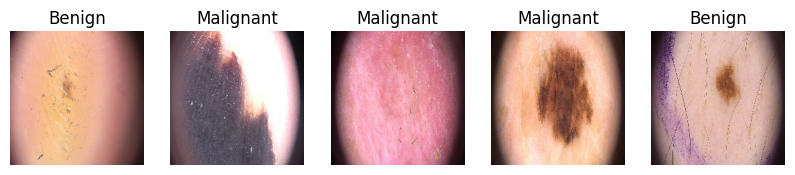

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = '/content/drive/MyDrive/train'
validation_dir = '/content/drive/MyDrive/validation'

train_datagen = ImageDataGenerator(rescale=1.0/255)
validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

sample_images, sample_labels = next(train_generator)
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(sample_images[i])
    plt.title('Benign' if sample_labels[i] == 0 else 'Malignant')
    plt.axis('off')
plt.show()

Found 1246 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📂 Fold 1
Epoch 1/100
38/38 - 5s - 120ms/step - accuracy: 0.5960 - loss: 0.7528 - val_accuracy: 0.6846 - val_loss: 0.5908 - learning_rate: 2.0000e-05
Epoch 2/100
38/38 - 5s - 121ms/step - accuracy: 0.6886 - loss: 0.6124 - val_accuracy: 0.7282 - val_loss: 0.5419 - learning_rate: 2.0000e-05
Epoch 3/100
38/38 - 2s - 50ms/step - accuracy: 0.7348 - loss: 0.5661 - val_accuracy: 0.7383 - val_loss: 0.5102 - learning_rate: 2.0000e-05
Epoch 4/100
38/38 - 1s - 39ms/step - accuracy: 0.7508 - loss: 0.5512 - val_accuracy: 0.7550 - val_loss: 0.4864 - learning_rate: 2.0000e-05
Epoch 5/100
38/38 - 1s - 31ms/step - accuracy: 0.7719 - loss: 0.4982 - val_accuracy: 0.7617 - val_loss: 0.4739 - learning_rate: 2.0000e-05
Epoch 6/100
38/38 - 1s - 31ms/step - accuracy: 0.7929 - loss: 0.4676 - val_accuracy: 0.7785 - val_loss: 0.4630 - learning_rate: 2.0000e-05
Epoch 7/100
38/38 - 1s - 33ms/step - accuracy: 0.8131 - loss:

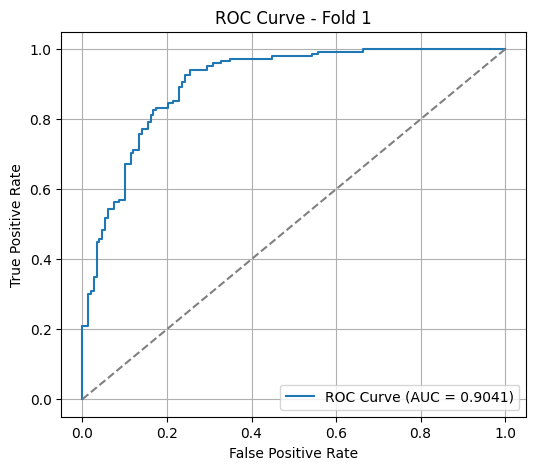

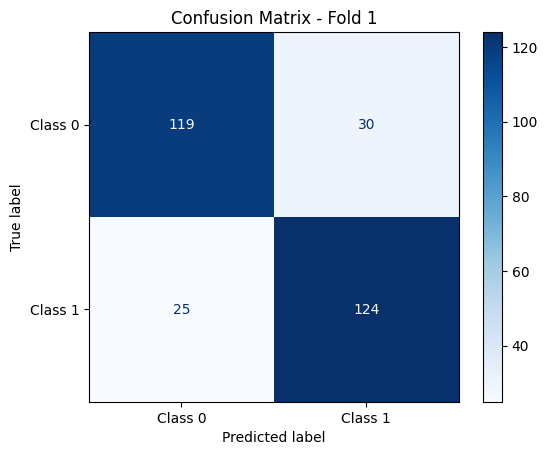

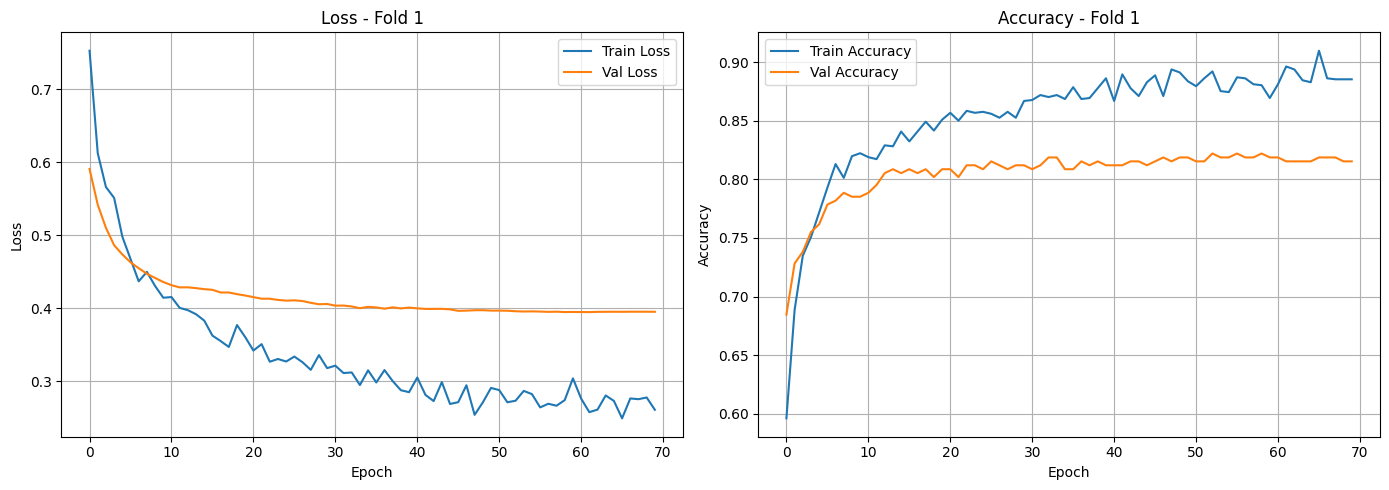


📂 Fold 2
Epoch 1/100
38/38 - 5s - 120ms/step - accuracy: 0.5694 - loss: 0.7726 - val_accuracy: 0.7306 - val_loss: 0.5490 - learning_rate: 2.0000e-05
Epoch 2/100
38/38 - 4s - 104ms/step - accuracy: 0.6964 - loss: 0.6032 - val_accuracy: 0.7744 - val_loss: 0.4886 - learning_rate: 2.0000e-05
Epoch 3/100
38/38 - 1s - 35ms/step - accuracy: 0.7334 - loss: 0.5425 - val_accuracy: 0.7980 - val_loss: 0.4593 - learning_rate: 2.0000e-05
Epoch 4/100
38/38 - 2s - 66ms/step - accuracy: 0.7536 - loss: 0.5373 - val_accuracy: 0.8148 - val_loss: 0.4419 - learning_rate: 2.0000e-05
Epoch 5/100
38/38 - 1s - 32ms/step - accuracy: 0.7855 - loss: 0.4850 - val_accuracy: 0.8182 - val_loss: 0.4291 - learning_rate: 2.0000e-05
Epoch 6/100
38/38 - 1s - 37ms/step - accuracy: 0.7847 - loss: 0.4849 - val_accuracy: 0.8283 - val_loss: 0.4184 - learning_rate: 2.0000e-05
Epoch 7/100
38/38 - 3s - 83ms/step - accuracy: 0.7939 - loss: 0.4516 - val_accuracy: 0.8350 - val_loss: 0.4100 - learning_rate: 2.0000e-05
Epoch 8/100
38/

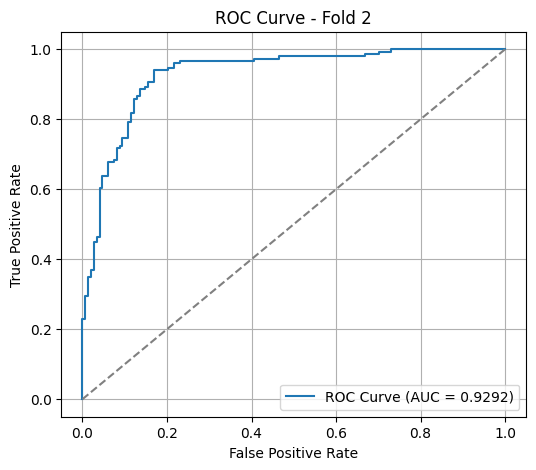

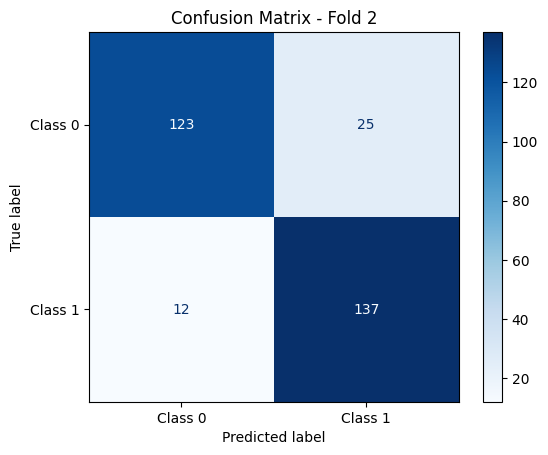

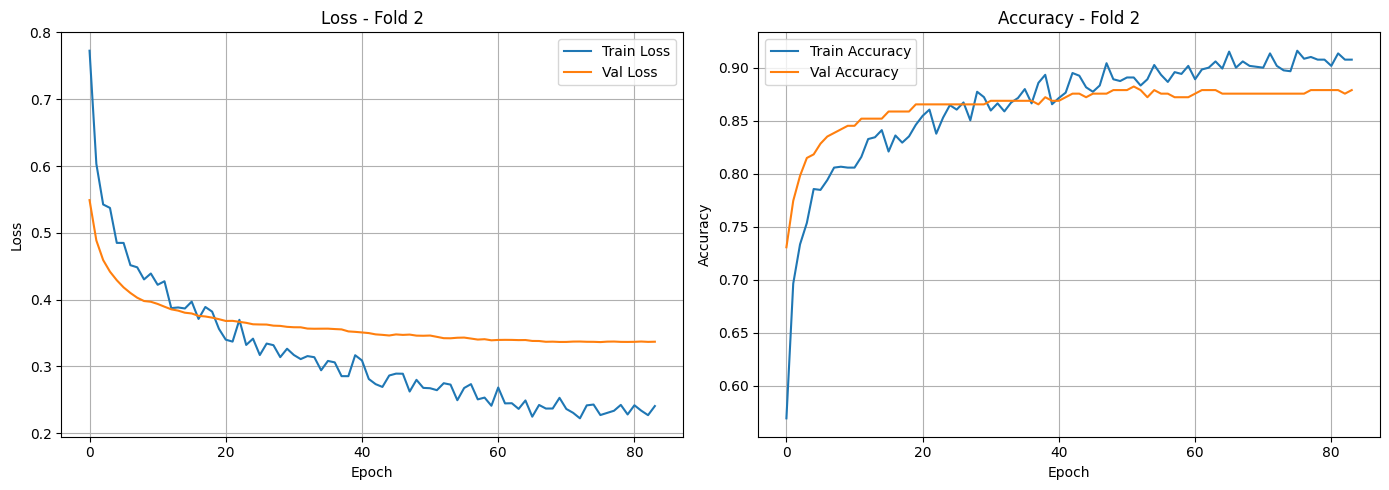


📂 Fold 3
Epoch 1/100
38/38 - 3s - 91ms/step - accuracy: 0.5896 - loss: 0.8083 - val_accuracy: 0.7239 - val_loss: 0.5276 - learning_rate: 2.0000e-05
Epoch 2/100
38/38 - 2s - 51ms/step - accuracy: 0.6510 - loss: 0.6699 - val_accuracy: 0.7609 - val_loss: 0.4622 - learning_rate: 2.0000e-05
Epoch 3/100
38/38 - 1s - 34ms/step - accuracy: 0.7199 - loss: 0.6115 - val_accuracy: 0.7879 - val_loss: 0.4216 - learning_rate: 2.0000e-05
Epoch 4/100
38/38 - 1s - 35ms/step - accuracy: 0.7527 - loss: 0.5516 - val_accuracy: 0.8081 - val_loss: 0.3968 - learning_rate: 2.0000e-05
Epoch 5/100
38/38 - 3s - 69ms/step - accuracy: 0.7569 - loss: 0.5604 - val_accuracy: 0.8283 - val_loss: 0.3776 - learning_rate: 2.0000e-05
Epoch 6/100
38/38 - 2s - 49ms/step - accuracy: 0.7805 - loss: 0.5110 - val_accuracy: 0.8350 - val_loss: 0.3639 - learning_rate: 2.0000e-05
Epoch 7/100
38/38 - 2s - 59ms/step - accuracy: 0.7830 - loss: 0.5069 - val_accuracy: 0.8519 - val_loss: 0.3542 - learning_rate: 2.0000e-05
Epoch 8/100
38/38

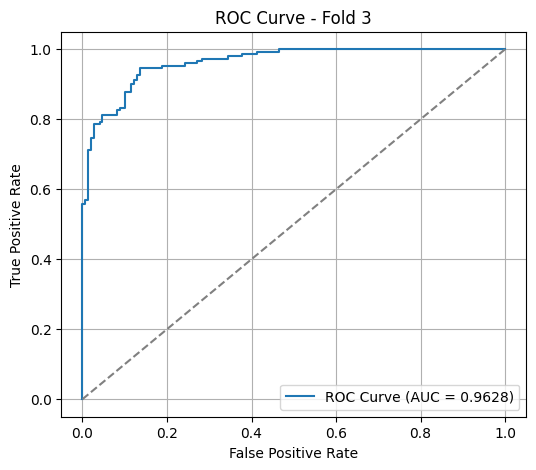

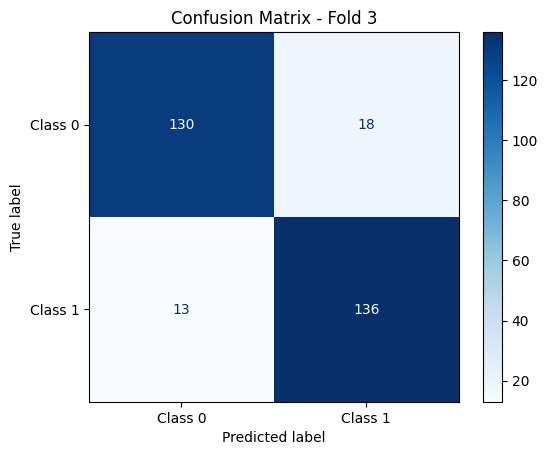

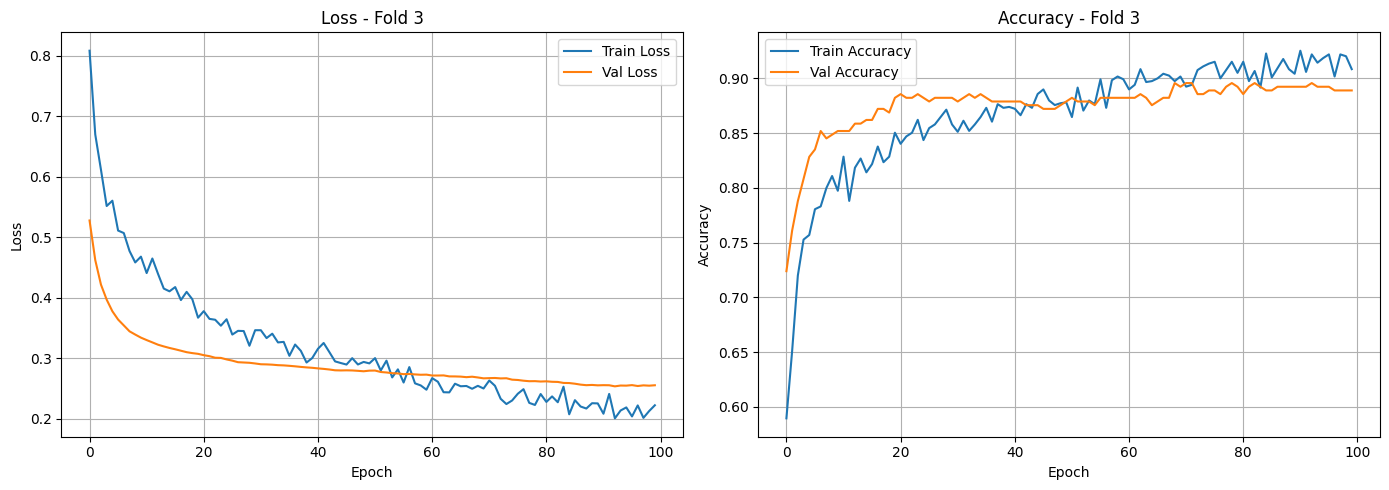


📂 Fold 4
Epoch 1/100
38/38 - 4s - 99ms/step - accuracy: 0.6081 - loss: 0.7718 - val_accuracy: 0.6869 - val_loss: 0.5770 - learning_rate: 2.0000e-05
Epoch 2/100
38/38 - 2s - 41ms/step - accuracy: 0.6678 - loss: 0.6705 - val_accuracy: 0.7475 - val_loss: 0.5208 - learning_rate: 2.0000e-05
Epoch 3/100
38/38 - 2s - 65ms/step - accuracy: 0.7199 - loss: 0.6023 - val_accuracy: 0.7811 - val_loss: 0.4919 - learning_rate: 2.0000e-05
Epoch 4/100
38/38 - 2s - 49ms/step - accuracy: 0.7569 - loss: 0.5516 - val_accuracy: 0.7845 - val_loss: 0.4780 - learning_rate: 2.0000e-05
Epoch 5/100
38/38 - 2s - 55ms/step - accuracy: 0.7502 - loss: 0.5166 - val_accuracy: 0.7946 - val_loss: 0.4652 - learning_rate: 2.0000e-05
Epoch 6/100
38/38 - 2s - 63ms/step - accuracy: 0.7561 - loss: 0.5091 - val_accuracy: 0.8047 - val_loss: 0.4549 - learning_rate: 2.0000e-05
Epoch 7/100
38/38 - 1s - 38ms/step - accuracy: 0.7696 - loss: 0.4839 - val_accuracy: 0.8182 - val_loss: 0.4478 - learning_rate: 2.0000e-05
Epoch 8/100
38/38

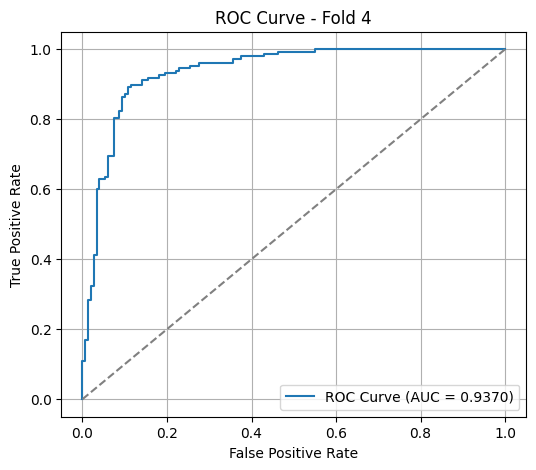

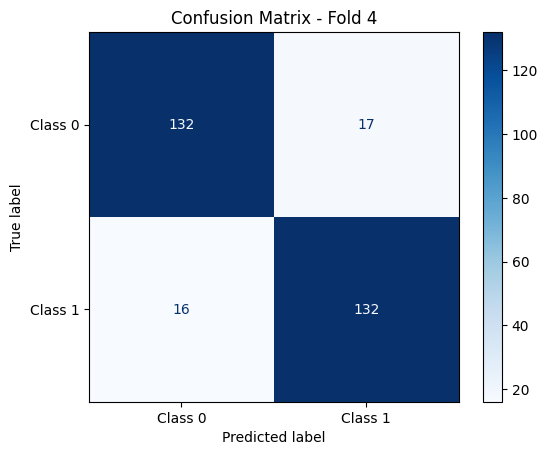

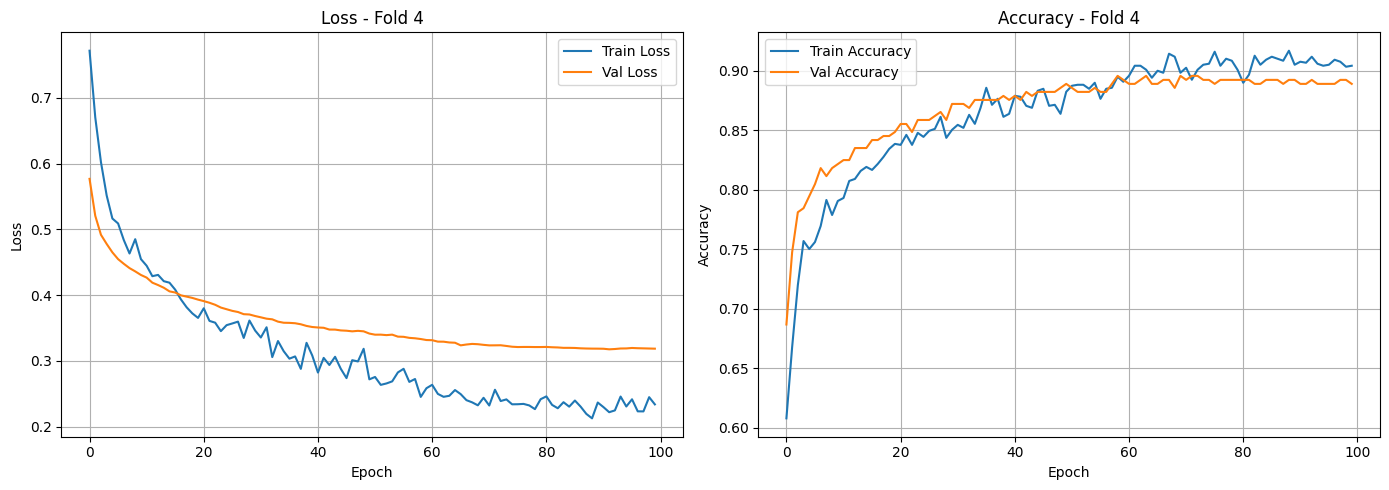


📂 Fold 5
Epoch 1/100
38/38 - 6s - 151ms/step - accuracy: 0.5988 - loss: 0.7216 - val_accuracy: 0.7508 - val_loss: 0.5306 - learning_rate: 2.0000e-05
Epoch 2/100
38/38 - 2s - 40ms/step - accuracy: 0.7006 - loss: 0.5967 - val_accuracy: 0.7811 - val_loss: 0.4611 - learning_rate: 2.0000e-05
Epoch 3/100
38/38 - 2s - 40ms/step - accuracy: 0.7166 - loss: 0.5456 - val_accuracy: 0.8249 - val_loss: 0.4279 - learning_rate: 2.0000e-05
Epoch 4/100
38/38 - 2s - 62ms/step - accuracy: 0.7401 - loss: 0.5302 - val_accuracy: 0.8316 - val_loss: 0.4067 - learning_rate: 2.0000e-05
Epoch 5/100
38/38 - 3s - 68ms/step - accuracy: 0.7603 - loss: 0.5115 - val_accuracy: 0.8384 - val_loss: 0.3907 - learning_rate: 2.0000e-05
Epoch 6/100
38/38 - 3s - 78ms/step - accuracy: 0.7906 - loss: 0.4792 - val_accuracy: 0.8418 - val_loss: 0.3797 - learning_rate: 2.0000e-05
Epoch 7/100
38/38 - 2s - 50ms/step - accuracy: 0.7855 - loss: 0.4700 - val_accuracy: 0.8485 - val_loss: 0.3704 - learning_rate: 2.0000e-05
Epoch 8/100
38/3

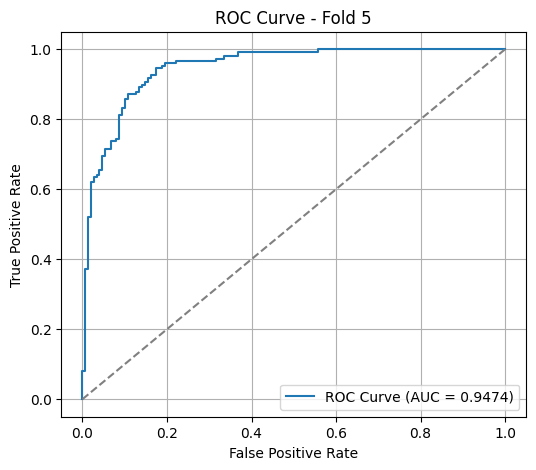

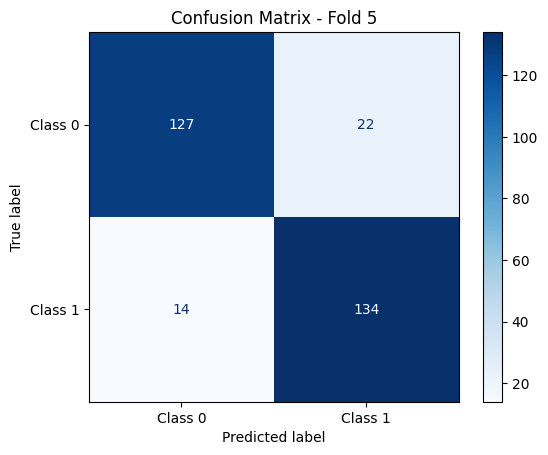

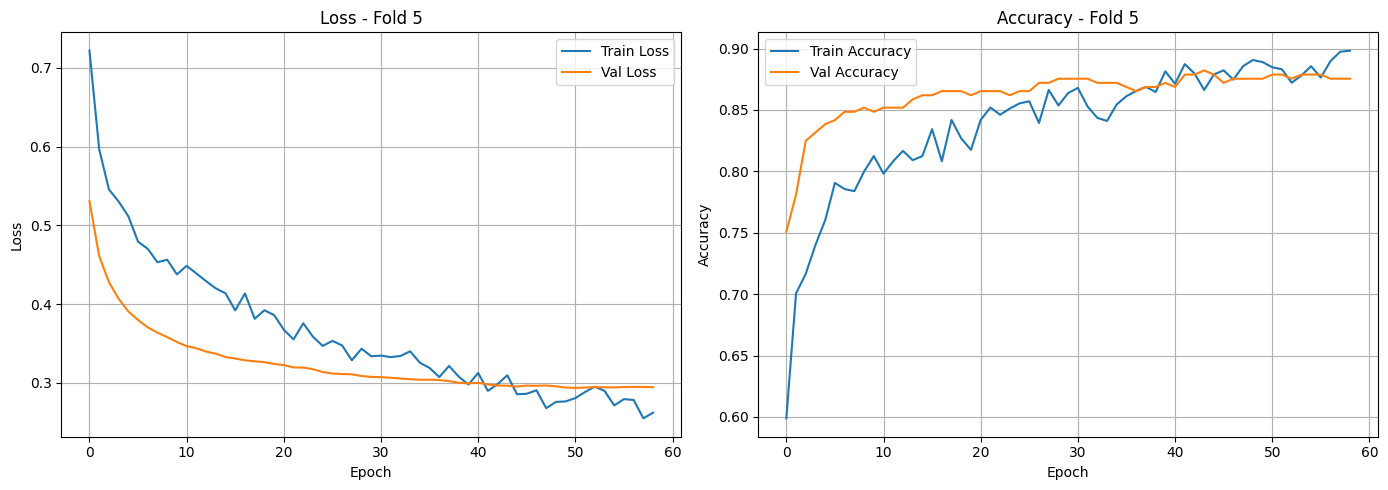

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

train_dir = '/content/drive/MyDrive/train'

img_size = (299, 299)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    fill_mode='nearest'
)
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=img_size, batch_size=32, class_mode='binary', shuffle=True
)

base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
for layer in base_model.layers[:-100]:
    layer.trainable = False
for layer in base_model.layers[-100:]:
    layer.trainable = True
feature_extractor = models.Model(inputs=base_model.input, outputs=base_model.output)

X_features, y_labels = [], []
for i, (images, labels) in enumerate(train_generator):
    features = feature_extractor.predict(images, verbose=0)
    X_features.append(features)
    y_labels.append(labels)
    if i >= len(train_generator) - 1:
        break

X = np.vstack(X_features)
y = np.hstack(y_labels)

X_flat = X.reshape(X.shape[0], -1)
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_flat, y)
X_scaled = StandardScaler().fit_transform(X_smote)
X_final = X_scaled.reshape(-1, X.shape[1], X.shape[2], X.shape[3])

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1

for train_idx, val_idx in kfold.split(X_final, y_smote):
    print(f"\n Fold {fold_no}")

    X_train, X_val = X_final[train_idx], X_final[val_idx]
    y_train, y_val = y_smote[train_idx], y_smote[val_idx]

    model = models.Sequential([
    layers.Input(shape=(5, 5, 2048)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.1),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

    model.compile(
        optimizer=Adam(learning_rate=2e-5),
        loss=BinaryCrossentropy(),
        metrics=['accuracy']
    )

    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(enumerate(class_weights))

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=2
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f" Fold {fold_no} - Accuracy: {val_acc:.4f}, Loss: {val_loss:.4f}")

    y_pred_prob = model.predict(X_val).flatten()
    y_pred_classes = (y_pred_prob > 0.5).astype("int32")

    print(classification_report(y_val, y_pred_classes))

    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - Fold {fold_no}')
    plt.legend()
    plt.grid(True)
    plt.show()

    cm = confusion_matrix(y_val, y_pred_classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - Fold {fold_no}")
    plt.grid(False)
    plt.show()

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'Accuracy - Fold {fold_no}')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Loss - Fold {fold_no}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    fold_no += 1

In [ ]:
####### پاتولوژی######

In [ ]:
import pandas as pd
from PIL import Image
import os
from google.colab import files
uploaded = files.upload()

Saving train - Copy.xlsx to train - Copy.xlsx
Saving validation - Copy.xlsx to validation - Copy.xlsx


In [ ]:
import os
import pandas as pd

train_image_dir = "/content/drive/MyDrive/train"
val_image_dir = "/content/drive/MyDrive/validation"

image_counts = {
    "train_malignant": 0,
    "train_benign": 0,
    "validation_malignant": 0,
    "validation_benign": 0
}

def get_correct_image_name(image_name):
    return image_name.strip().lower().replace(".jpg", "")

def check_and_count_images(image_name, dataset_type):
    image_name_corrected = get_correct_image_name(image_name)

    if dataset_type == "train":
        if os.path.exists(os.path.join(train_image_dir, "malignant", f"{image_name_corrected}.jpg")):
            image_counts["train_malignant"] += 1
            print(f"{image_name_corrected}.jpg belongs to train (malignant)")
        if os.path.exists(os.path.join(train_image_dir, "benign", f"{image_name_corrected}.jpg")):
            image_counts["train_benign"] += 1
            print(f"{image_name_corrected}.jpg belongs to train (benign)")

    elif dataset_type == "validation":
        if os.path.exists(os.path.join(val_image_dir, "malignant", f"{image_name_corrected}.jpg")):
            image_counts["validation_malignant"] += 1
            print(f"{image_name_corrected}.jpg belongs to validation (malignant)")
        if os.path.exists(os.path.join(val_image_dir, "benign", f"{image_name_corrected}.jpg")):
            image_counts["validation_benign"] += 1
            print(f"{image_name_corrected}.jpg belongs to validation (benign)")

train_df = pd.read_excel("train - Copy.xlsx")
val_df = pd.read_excel("validation - Copy.xlsx")

train_df["dermoscopy_image_path"] = train_df["dermoscopy_image_path"].apply(lambda x: f"{x.strip().lower()}.jpg")
val_df["dermoscopy_image_path"] = val_df["dermoscopy_image_path"].apply(lambda x: f"{x.strip().lower()}.jpg")

for image_name in train_df["dermoscopy_image_path"]:
    check_and_count_images(image_name, "train")

for image_name in val_df["dermoscopy_image_path"]:
    check_and_count_images(image_name, "validation")

total_images = sum(image_counts.values())
print("\nFinal Results:")
print(f"Total number of images: {total_images}")
print(f"تعداد تصاویر در فولدر train (malignant): {image_counts['train_malignant']}")
print(f"تعداد تصاویر در فولدر train (benign): {image_counts['train_benign']}")
print(f"تعداد تصاویر در فولدر validation (malignant): {image_counts['validation_malignant']}")
print(f"تعداد تصاویر در فولدر validation (benign): {image_counts['validation_benign']}")

p114.jpg belongs to train (malignant)
p114-1.jpg belongs to train (malignant)
p115.jpg belongs to train (malignant)
p115-1.jpg belongs to train (malignant)
p115-2.jpg belongs to train (malignant)
p112.jpg belongs to train (malignant)
p112-1.jpg belongs to train (malignant)
p112-2.jpg belongs to train (malignant)
p112-3.jpg belongs to train (malignant)
p112-4.jpg belongs to train (malignant)
p112-5.jpg belongs to train (malignant)
p20-1.jpg belongs to train (benign)
p20-2.jpg belongs to train (benign)
p111.jpg belongs to train (malignant)
p111-1.jpg belongs to train (malignant)
p111-3.jpg belongs to train (malignant)
p111-4.jpg belongs to train (malignant)
p111-5.jpg belongs to train (malignant)
p111-6.jpg belongs to train (malignant)
p111-7.jpg belongs to train (malignant)
p111-8.jpg belongs to train (malignant)
p107-1.jpg belongs to train (malignant)
p107-2.jpg belongs to train (malignant)
p107-3.jpg belongs to train (malignant)
p22-3.jpg belongs to train (malignant)
p22-7.jpg belongs

In [ ]:
import pandas as pd
import os

train_df = pd.read_excel('/content/train - Copy.xlsx')
validation_df = pd.read_excel('/content/validation - Copy.xlsx')

print("Train DataFrame:")
print(train_df.head())

print("\nValidation DataFrame:")
print(validation_df.head())

train_images_path = '/content/drive/MyDrive/train'
validation_images_path = '/content/drive/MyDrive/validation'

def get_image_path(row, base_path):
    diagnosis_folder = 'benign' if row['diagnosis'] == 0 else 'malignant'
    return os.path.join(base_path, diagnosis_folder, f"{row['dermoscopy_image_path']}.jpg")

train_df['image_path'] = train_df.apply(lambda row: get_image_path(row, train_images_path), axis=1)

validation_df['image_path'] = validation_df.apply(lambda row: get_image_path(row, validation_images_path), axis=1)

print("\nUpdated Train DataFrame with image paths:")
print(train_df[['dermoscopy_image_path', 'image_path']].head())

print("\nUpdated Validation DataFrame with image paths:")
print(validation_df[['dermoscopy_image_path', 'image_path']].head())

train_df.to_excel('/content/train_with_image_paths.xlsx', index=False)
validation_df.to_excel('/content/validation_with_image_paths.xlsx', index=False)

Train DataFrame:
  gender                                clinical_impression  \
0      f  Dysplastic nevus-Lentigo/SK-Lentigo maligna -I...   
1      f  Dysplastic nevus-Lentigo/SK-Lentigo maligna -I...   
2      f                         Malignant melanoma in situ   
3      f                         Malignant melanoma in situ   
4      f                         Malignant melanoma in situ   

                             macroscopic_description  \
0  three(3) paraff  and three (3) H&E glass slide...   
1  three(3) paraff  and three (3) H&E glass slide...   
2                                      0.4*0.3*0.3     
3                                      0.4*0.3*0.3     
4                                      0.4*0.3*0.3     

                             microscopic_description       location  \
0  epithelioid/spindle cell type   Vertical growt...  right forearm   
1  epithelioid/spindle cell type   Vertical growt...  right forearm   
2  mild hyperkeratosis, acanthosis, proliferated ...  

In [ ]:
def determine_malignancy(row):
    if row['diagnosis'] == 0:
        return 0

    # Breslow Depth
    breslow = row['breslow(mm)']
    if breslow == 0:
        breslow_grade = 1  # Low
    elif 1 <= breslow <= 4:
        breslow_grade = 2  # Medium
    else:
        breslow_grade = 3  # High

    # Clark Level
    clark = row['clark']
    if clark <= 2:
        clark_grade = 1  # Low
    elif 3 <= clark <= 4:
        clark_grade = 2  # Medium
    else:
        clark_grade = 3  # High

    # Ulceration
    ulceration = row['ulceration']
    if ulceration == 0:
        ulceration_grade = 1  # Low
    else:
        ulceration_grade = 3  # High

    # Mitotic Activity
    mitotic = row['mitotic']
    if mitotic < 1:
        mitotic_grade = 1
    elif 1 <= mitotic < 3:
        mitotic_grade = 2  # Medium
    else:
        mitotic_grade = 3  # High

    # نمره‌دهی نهایی به بدخیمی بر اساس ترکیب این ویژگی‌ها
    final_score = breslow_grade + clark_grade + ulceration_grade + mitotic_grade

    # تعیین درجه نهایی بدخیمی بر اساس نمره کلی
    if final_score >= 10:
        return 3  # High
    elif 7 <= final_score < 10:
        return 2  # Medium
    else:
        return 1  # Low

train_df['malignancy_grade'] = train_df.apply(determine_malignancy, axis=1)
print(train_df[['diagnosis', 'breslow(mm)', 'clark', 'ulceration', 'mitotic', 'malignancy_grade']].head())
validation_df['malignancy_grade'] = validation_df.apply(determine_malignancy, axis=1)
print(validation_df[['diagnosis', 'breslow(mm)', 'clark', 'ulceration', 'mitotic', 'malignancy_grade']].head())

   diagnosis  breslow(mm)  clark  ulceration  mitotic  malignancy_grade
0          1          3.0      3           0      1.5                 2
1          1          3.0      3           0      1.5                 2
2          1          0.0      0           0      0.0                 1
3          1          0.0      0           0      0.0                 1
4          1          0.0      0           0      0.0                 1
   diagnosis  breslow(mm)  clark  ulceration  mitotic  malignancy_grade
0          0          0.0      0           1      0.0                 0
1          0          0.0      0           0      0.0                 0
2          0          0.0      0           0      0.0                 0
3          0          0.0      0           0      0.0                 0
4          1          0.0      0           0      0.0                 1


In [ ]:
malignancy_grade_counts = train_df['malignancy_grade'].value_counts()

print("Counts of each diagnosis:")
print(malignancy_grade_counts)

malignancy_grade_counts = validation_df['malignancy_grade'].value_counts()

print("Counts of each diagnosis:")
print(malignancy_grade_counts)

Counts of each diagnosis:
malignancy_grade
0    217
1    189
2     59
3     13
Name: count, dtype: int64
Counts of each diagnosis:
malignancy_grade
0    62
1    44
2    16
3     8
Name: count, dtype: int64


In [ ]:
import pandas as pd

train_df = pd.read_excel('/content/train_with_image_paths.xlsx')
val_df = pd.read_excel('/content/validation_with_image_paths.xlsx')

def determine_malignancy(row):
    if row['diagnosis'] == 0:
        return 0

    # Breslow Depth
    breslow = row['breslow(mm)']
    if pd.isna(breslow):
        breslow_grade = 1
    elif breslow == 0:
        breslow_grade = 1
    elif 1 <= breslow <= 4:
        breslow_grade = 2
    else:
        breslow_grade = 3

    # Clark Level
    clark = row['clark']
    if pd.isna(clark):
        clark_grade = 1
    elif clark <= 2:
        clark_grade = 1
    elif 3 <= clark <= 4:
        clark_grade = 2
    else:
        clark_grade = 3

    # Ulceration
    ulceration = row['ulceration']
    if pd.isna(ulceration) or ulceration == 0:
        ulceration_grade = 1
    else:
        ulceration_grade = 3

    # Mitotic Activity
    mitotic = row['mitotic']
    if pd.isna(mitotic) or mitotic < 1:
        mitotic_grade = 1
    elif 1 <= mitotic < 3:
        mitotic_grade = 2
    else:
        mitotic_grade = 3

    final_score = breslow_grade + clark_grade + ulceration_grade + mitotic_grade

    if final_score >= 10:
        return 3
    elif 7 <= final_score < 10:
        return 2
    else:
        return 1

train_df['malignancy_grade'] = train_df.apply(determine_malignancy, axis=1)
val_df['malignancy_grade'] = val_df.apply(determine_malignancy, axis=1)

train_df.to_excel('/content/train_with_malignancy_grade.xlsx', index=False)
val_df.to_excel('/content/validation_with_malignancy_grade.xlsx', index=False)

print(" ستون malignancy_grade با موفقیت اضافه و ذخیره شد.")

✅ ستون malignancy_grade با موفقیت اضافه و ذخیره شد.


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm

train_df = pd.read_excel('/content/train_with_malignancy_grade.xlsx')
val_df = pd.read_excel('/content/validation_with_malignancy_grade.xlsx')

train_df = train_df[~train_df['malignancy_grade'].isna()]
val_df = val_df[~val_df['malignancy_grade'].isna()]
train_df['malignancy_grade'] = train_df['malignancy_grade'].astype(int)
val_df['malignancy_grade'] = val_df['malignancy_grade'].astype(int)

all_df = pd.concat([train_df, val_df], ignore_index=True)
all_labels = all_df['malignancy_grade'].values
all_paths = all_df['image_path'].values

def load_and_preprocess_image(path):
    try:
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = tf.keras.applications.inception_v3.preprocess_input(img_array)
        return img_array
    except:
        print(f" خطا در بارگذاری تصویر: {path}")
        return None

print(" بارگذاری و پیش‌پردازش تصاویر...")
images, valid_labels = [], []
for path, label in tqdm(zip(all_paths, all_labels), total=len(all_paths)):
    img = load_and_preprocess_image(path)
    if img is not None:
        images.append(img)
        valid_labels.append(label)

images = np.array(images)
labels = to_categorical(valid_labels, num_classes=4)

print(" استخراج ویژگی‌ها با InceptionV3...")
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
features = base_model.predict(images, verbose=1)

X_flat = features.reshape(features.shape[0], -1)
y_raw = np.argmax(labels, axis=1)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y_raw)
y_res_cat = to_categorical(y_resampled, num_classes=4)
X_resampled = X_resampled.reshape(-1, 5, 5, 2048)

X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_res_cat, test_size=0.2, stratify=y_resampled, random_state=42
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_resampled), y=y_resampled)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

model = models.Sequential([
    layers.Input(shape=(5, 5, 2048)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.1),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7),
    ModelCheckpoint('malignancy_inception_model.keras', monitor='val_accuracy', save_best_only=True)
]
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\n Validation Accuracy: {val_acc:.4f}")
print(f" Validation Loss: {val_loss:.4f}")

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)
print("\n📊 Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes))

✅ بارگذاری و پیش‌پردازش تصاویر...


 25%|██▌       | 155/608 [00:43<02:09,  3.51it/s]

❌ خطا در بارگذاری تصویر: /content/drive/MyDrive/train/malignant/p1 .jpg


100%|██████████| 608/608 [02:37<00:00,  3.85it/s]


📦 استخراج ویژگی‌ها با InceptionV3...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 87s 4s/step
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.2902 - loss: 1.7700 - val_accuracy: 0.4821 - val_loss: 1.2138 - learning_rate: 2.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3520 - loss: 1.5301 - val_accuracy: 0.5759 - val_loss: 1.0700 - learning_rate: 2.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4228 - loss: 1.4168 - val_accuracy: 0.6295 - val_loss: 0.9781 - learning_rate: 2.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5114 - loss: 1.2683 - val_accuracy: 0.6696 - val_loss: 0.9094 - learning_rate: 2.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.5234 - loss: 1.2314 - val_accuracy: 0.7009 - val_loss: 0.8623 - learning_rate: 2.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.5441 - loss: 1.1177 - val_a

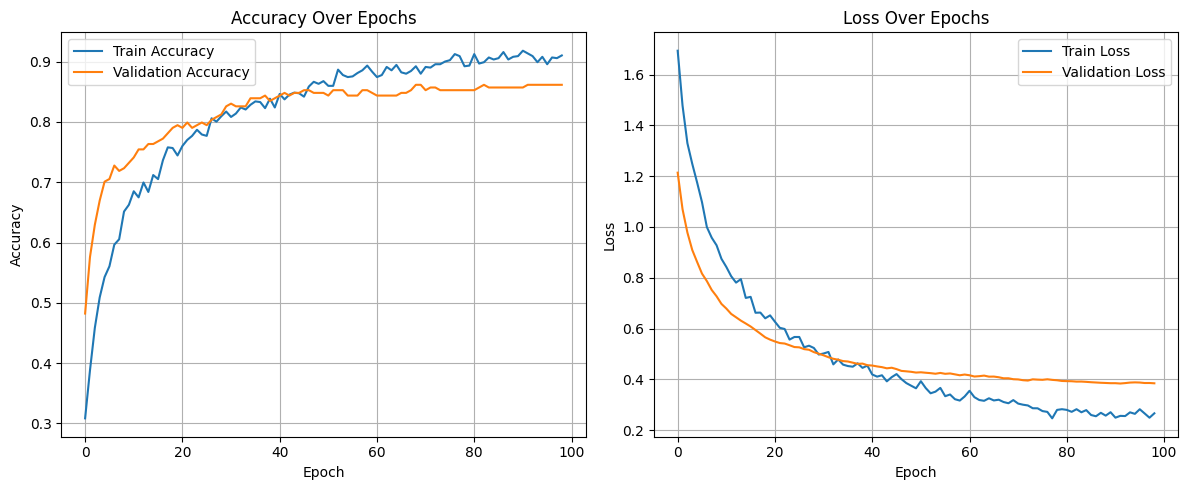

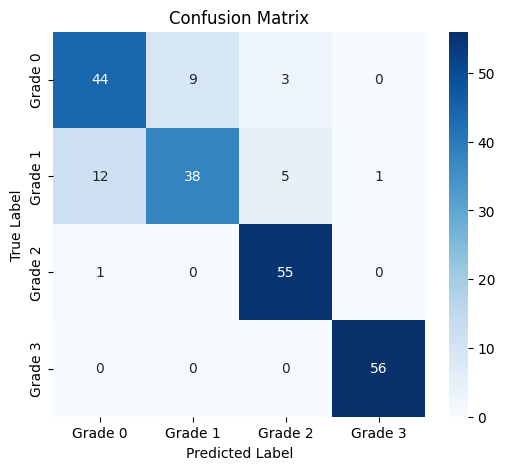

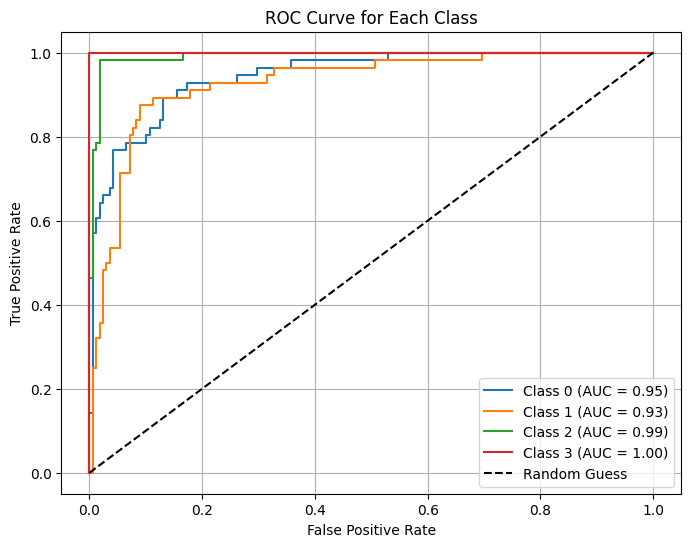

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_classes, y_pred_classes)
labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_val_bin = label_binarize(y_true_classes, classes=[0, 1, 2, 3])
y_pred_bin = y_pred

fpr = {}
tpr = {}
roc_auc = {}
n_classes = 4

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve for Each Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm

train_df = pd.read_excel('/content/train_with_malignancy_grade.xlsx')
val_df = pd.read_excel('/content/validation_with_malignancy_grade.xlsx')

train_df = train_df[~train_df['malignancy_grade'].isna()]
val_df = val_df[~val_df['malignancy_grade'].isna()]
train_df['malignancy_grade'] = train_df['malignancy_grade'].astype(int)
val_df['malignancy_grade'] = val_df['malignancy_grade'].astype(int)

all_df = pd.concat([train_df, val_df], ignore_index=True)
all_labels = all_df['malignancy_grade'].values
all_paths = all_df['image_path'].values

def load_and_preprocess_image(path):
    try:
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array = tf.keras.applications.inception_v3.preprocess_input(img_array)
        return img_array
    except:
        print(f" خطا در بارگذاری تصویر: {path}")
        return None

print(" بارگذاری و پیش‌پردازش تصاویر...")
images, valid_labels = [], []
for path, label in tqdm(zip(all_paths, all_labels), total=len(all_paths)):
    img = load_and_preprocess_image(path)
    if img is not None:
        images.append(img)
        valid_labels.append(label)

images = np.array(images)
labels = to_categorical(valid_labels, num_classes=4)

print(" استخراج ویژگی‌ها با InceptionV3...")
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
features = base_model.predict(images, verbose=1)

X_flat = features.reshape(features.shape[0], -1)
y_raw = np.argmax(labels, axis=1)
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_flat, y_raw)

y_res_cat = to_categorical(y_resampled, num_classes=4)
X_resampled = X_resampled.reshape(-1, 5, 5, 2048)

X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_res_cat, test_size=0.2, stratify=y_resampled, random_state=42
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_resampled), y=y_resampled)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

model = models.Sequential([
    layers.Input(shape=(5, 5, 2048)),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(512),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.1),
    layers.Dropout(0.3),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7),
    ModelCheckpoint('malignancy_inception_model.keras', monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\n Validation Accuracy: {val_acc:.4f}")
print(f" Validation Loss: {val_loss:.4f}")

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)
print("\n Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes))

✅ بارگذاری و پیش‌پردازش تصاویر...


 25%|██▌       | 155/608 [00:56<02:51,  2.65it/s]

❌ خطا در بارگذاری تصویر: /content/drive/MyDrive/train/malignant/p1 .jpg


100%|██████████| 608/608 [03:34<00:00,  2.84it/s]


📦 استخراج ویژگی‌ها با InceptionV3...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.2748 - loss: 1.6802 - val_accuracy: 0.3973 - val_loss: 1.2867 - learning_rate: 2.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.3590 - loss: 1.4824 - val_accuracy: 0.5357 - val_loss: 1.0949 - learning_rate: 2.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4563 - loss: 1.3001 - val_accuracy: 0.6027 - val_loss: 0.9651 - learning_rate: 2.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4941 - loss: 1.2177 - val_accuracy: 0.6518 - val_loss: 0.8724 - learning_rate: 2.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5759 - loss: 1.0798 - val_accuracy: 0.7054 - val_loss: 0.7998 - learning_rate: 2.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5510 - loss: 1.0238 - val_a

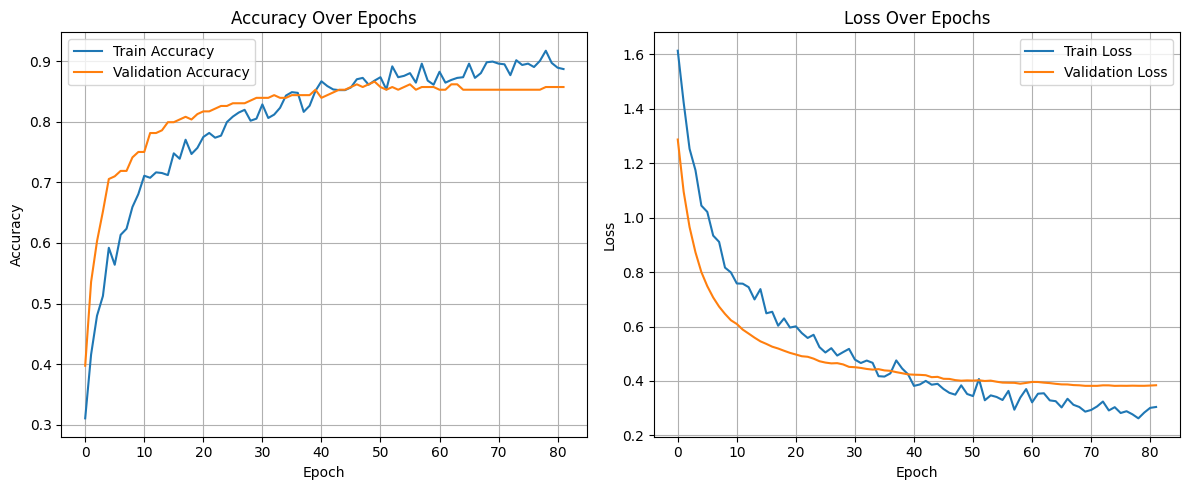

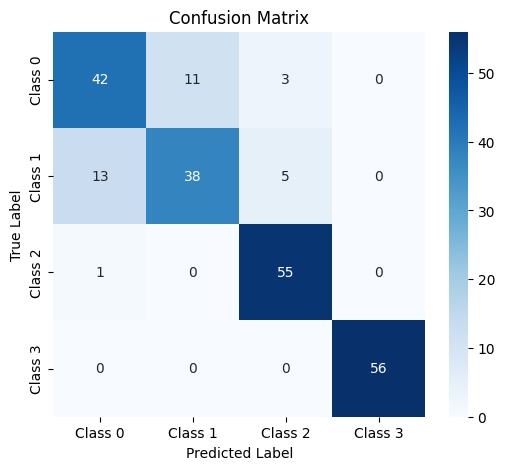

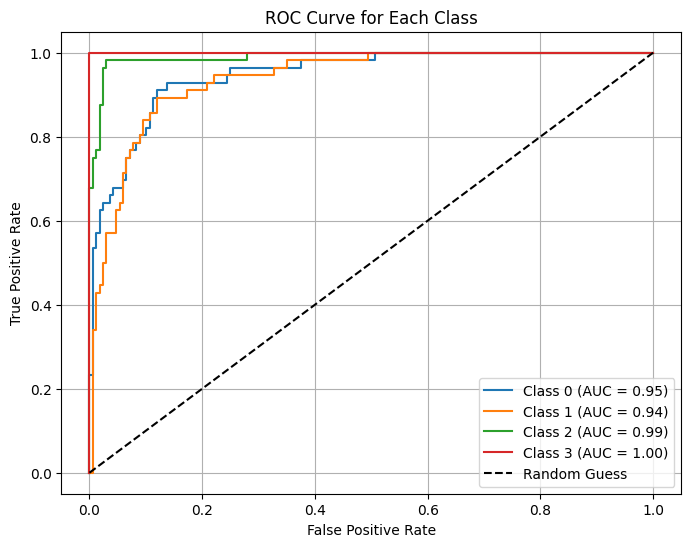

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_classes, y_pred_classes)
labels = ['Class 0', 'Class 1', 'Class 2', 'Class 3']

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_val_bin = label_binarize(y_true_classes, classes=[0, 1, 2, 3])
y_pred_bin = y_pred

fpr = {}
tpr = {}
roc_auc = {}
n_classes = 4

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curve for Each Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
################### VGG  #########################

Found 1246 images belonging to 2 classes.
Found 309 images belonging to 2 classes.
Epoch 1/100
35/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5659 - loss: 0.7060
Epoch 1: val_accuracy improved from -inf to 0.75168, saving model to best_model_vgg16.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.5709 - loss: 0.7024 - val_accuracy: 0.7517 - val_loss: 0.5652 - learning_rate: 1.0000e-04
Epoch 2/100
35/38 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7051 - loss: 0.5778
Epoch 2: val_accuracy improved from 0.75168 to 0.79866, saving model to best_model_vgg16.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.7050 - loss: 0.5781 - val_accuracy: 0.7987 - val_loss: 0.5142 - learning_rate: 1.0000e-04
Epoch 3/100
34/38 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7148 - loss: 0.5718
Epoch 3: val_accuracy improved from 0.79866 to 0.80201, saving model to best_model_vgg16.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7170 - loss: 0.5697 - val_accuracy:

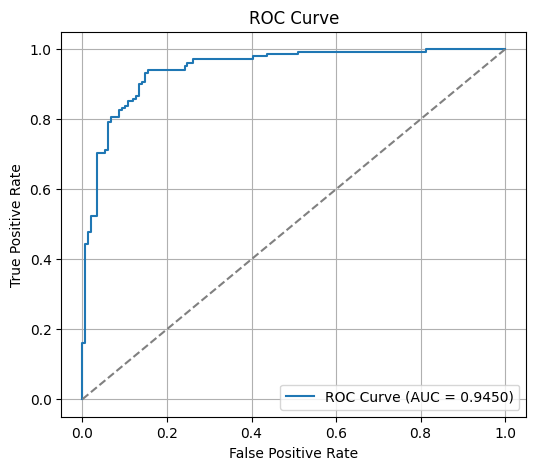

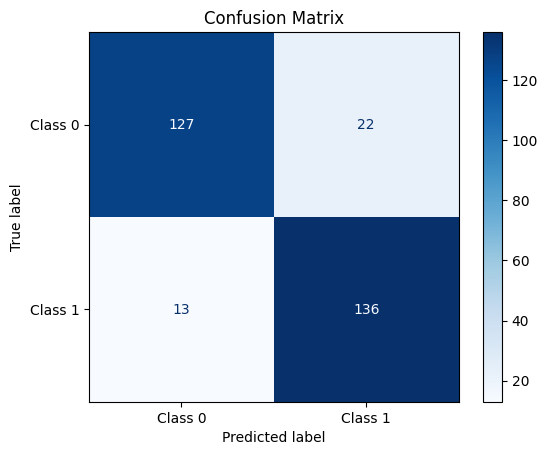

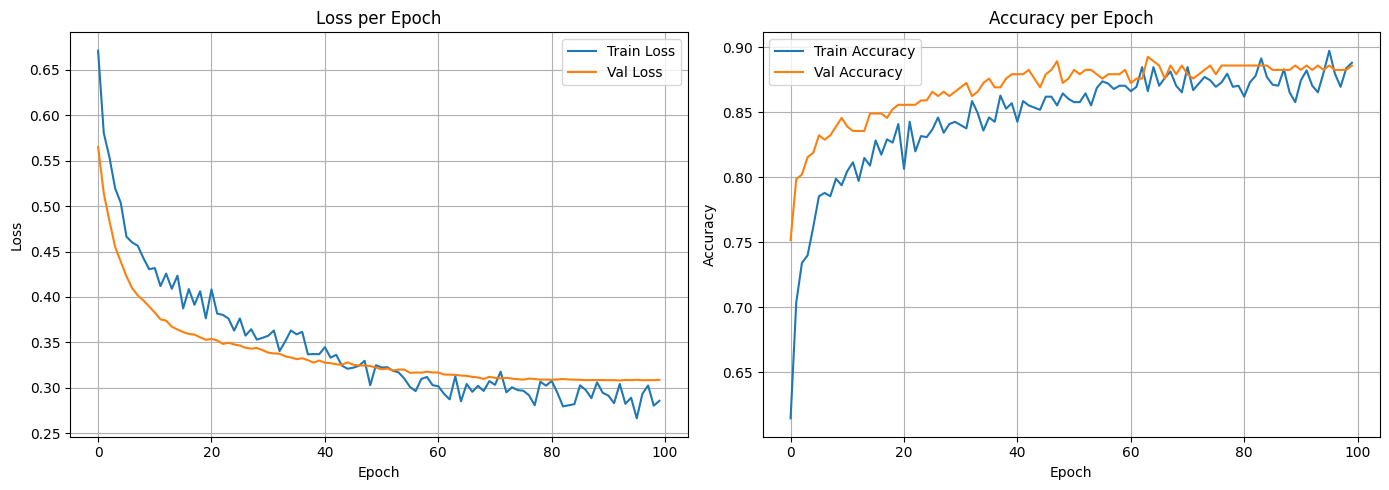

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

train_dir = '/content/drive/MyDrive/train'
validation_dir = '/content/drive/MyDrive/validation'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=True
)
validation_generator = validation_datagen.flow_from_directory(
    validation_dir, target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:-4]:
    layer.trainable = False
for layer in base_model.layers[-4:]:
    layer.trainable = True

feature_extractor = models.Model(inputs=base_model.input, outputs=base_model.output)

X_train_features, y_train_labels = [], []
for i, (images, labels) in enumerate(train_generator):
    features = feature_extractor.predict(images, verbose=0)
    X_train_features.append(features)
    y_train_labels.append(labels)
    if i >= len(train_generator) - 1:
        break

X_train_features = np.vstack(X_train_features)
y_train_labels = np.hstack(y_train_labels)

X_flat = X_train_features.reshape(X_train_features.shape[0], -1)
X_resampled_flat, y_resampled = SMOTE(random_state=42).fit_resample(X_flat, y_train_labels)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled_flat)
X_resampled = X_scaled.reshape(-1, X_train_features.shape[1], X_train_features.shape[2], X_train_features.shape[3])

X_train, X_val, y_train, y_val = train_test_split(
    X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.LeakyReLU(0.1),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

callbacks = [
    EarlyStopping(patience=7, monitor='val_loss', restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, verbose=1),
    ModelCheckpoint("best_model_vgg16.keras", monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print(f"\n Validation Accuracy: {val_acc:.4f}")
print(f" Validation Loss: {val_loss:.4f}")

y_pred = model.predict(X_val)
y_pred_classes = (y_pred > 0.5).astype("int32").flatten()
print("\n Classification Report:\n", classification_report(y_val, y_pred_classes))

fpr, tpr, _ = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

cm = confusion_matrix(y_val, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🔁 Fold 1/5 ----------------------------------------

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.81      0.85       149
         1.0       0.83      0.91      0.87       149

    accuracy                           0.86       298
   macro avg       0.86      0.86      0.86       298
weighted avg       0.86      0.86      0.86       298



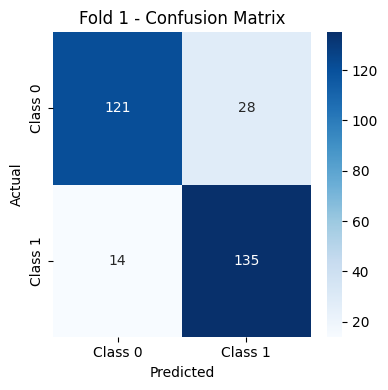

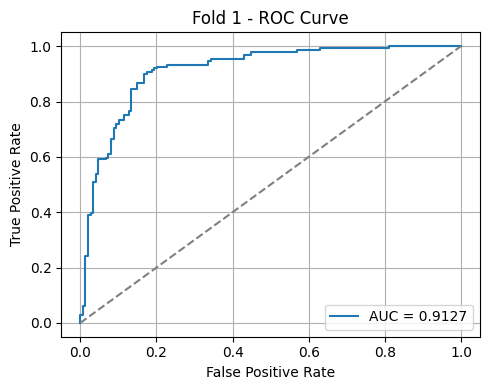

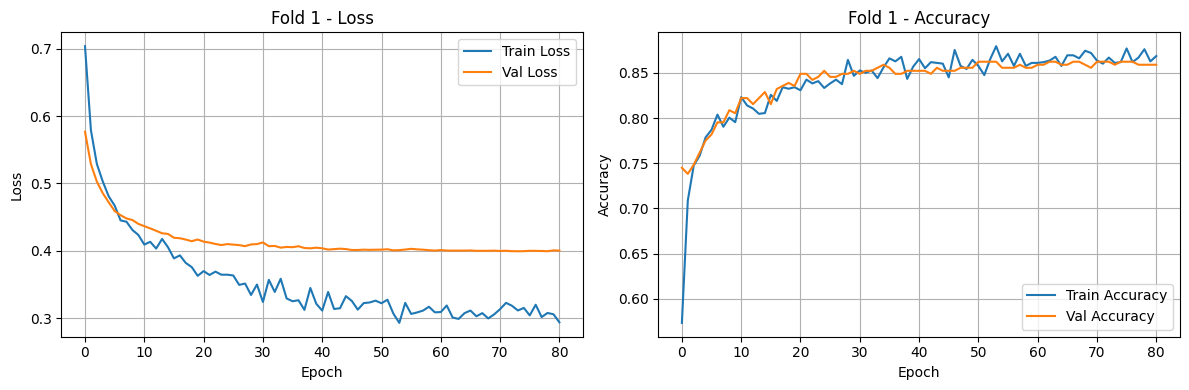


🔁 Fold 2/5 ----------------------------------------

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.85      0.85       149
         1.0       0.85      0.85      0.85       148

    accuracy                           0.85       297
   macro avg       0.85      0.85      0.85       297
weighted avg       0.85      0.85      0.85       297



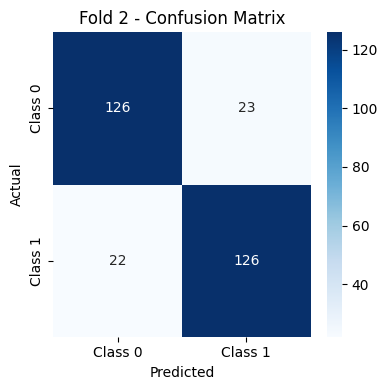

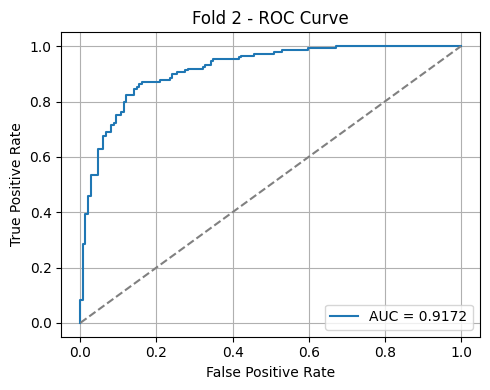

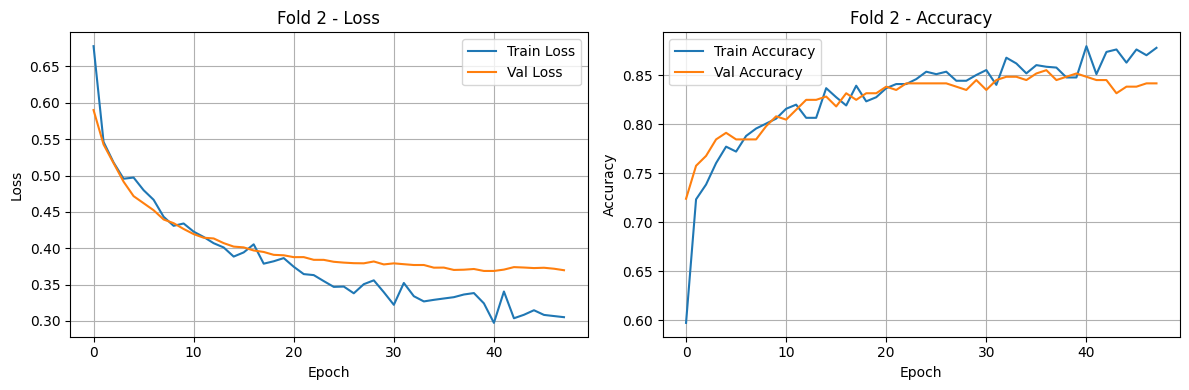


🔁 Fold 3/5 ----------------------------------------

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.84      0.91      0.87       149
         1.0       0.90      0.82      0.86       148

    accuracy                           0.87       297
   macro avg       0.87      0.87      0.87       297
weighted avg       0.87      0.87      0.87       297



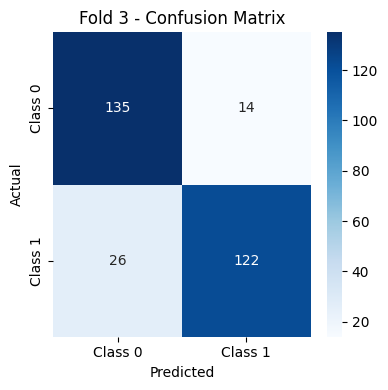

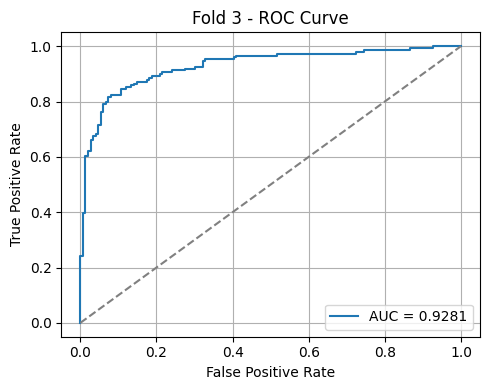

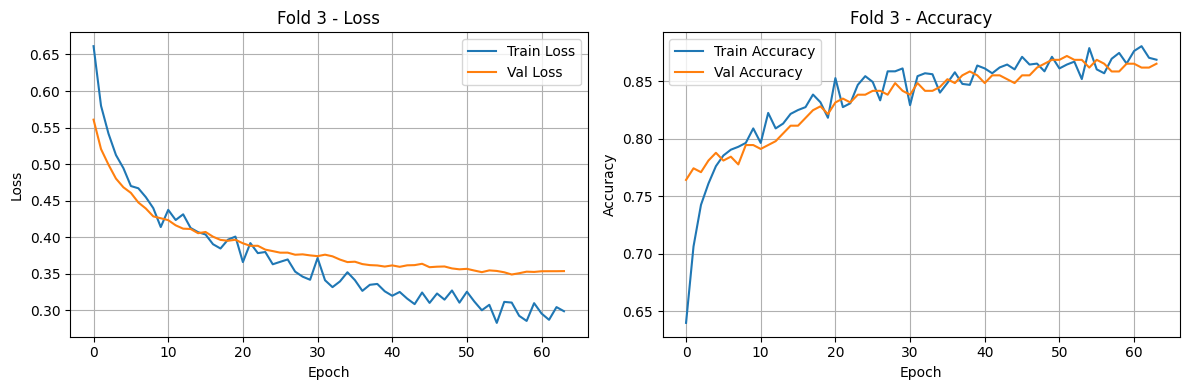


🔁 Fold 4/5 ----------------------------------------

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.82      0.84       148
         1.0       0.83      0.86      0.84       149

    accuracy                           0.84       297
   macro avg       0.84      0.84      0.84       297
weighted avg       0.84      0.84      0.84       297



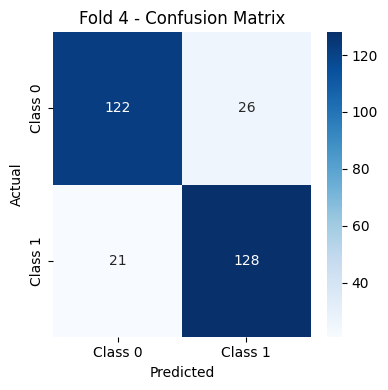

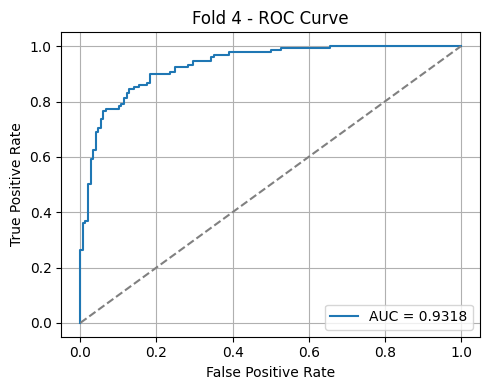

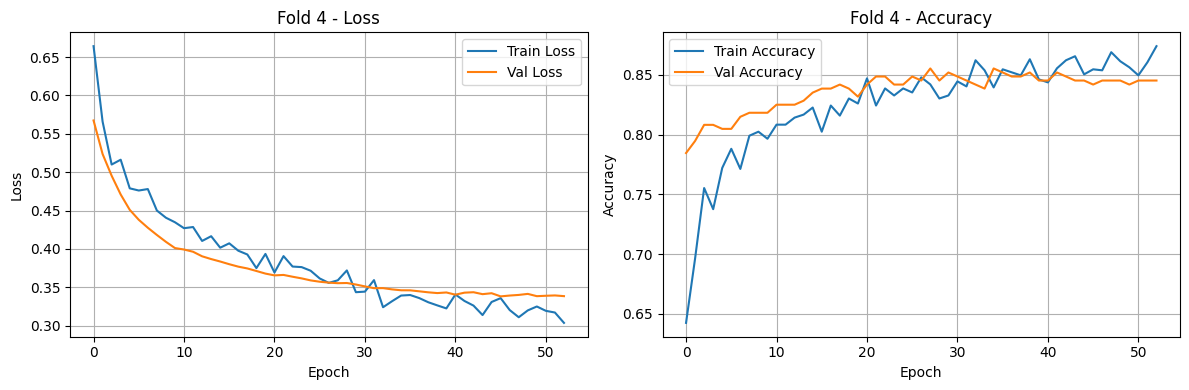


🔁 Fold 5/5 ----------------------------------------

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.82      0.85       148
         1.0       0.84      0.89      0.86       149

    accuracy                           0.86       297
   macro avg       0.86      0.86      0.86       297
weighted avg       0.86      0.86      0.86       297



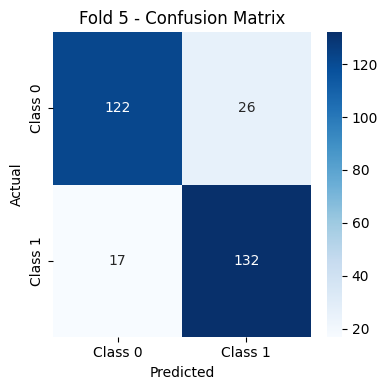

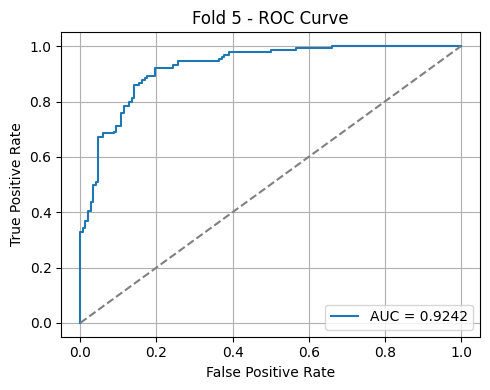

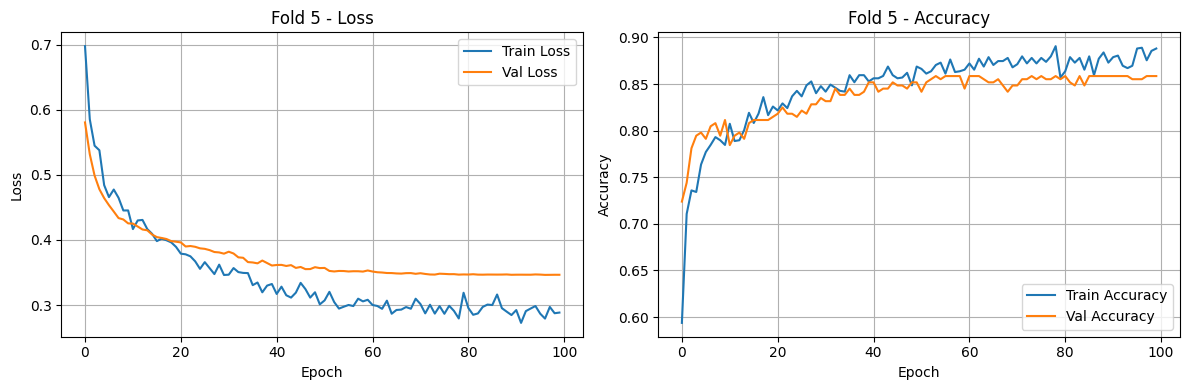

In [ ]:
from sklearn.model_selection import StratifiedKFold
import seaborn as sns

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_no = 1

for train_idx, val_idx in skf.split(X_resampled, y_resampled):
    print(f"\n Fold {fold_no}/{n_splits} {'-'*40}")

    X_train, X_val = X_resampled[train_idx], X_resampled[val_idx]
    y_train, y_val = y_resampled[train_idx], y_resampled[val_idx]

    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(enumerate(class_weights))

    model = models.Sequential([
        layers.Input(shape=X_train.shape[1:]),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.1),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=BinaryCrossentropy(),
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(patience=7, monitor='val_loss', restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, verbose=0),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=0
    )

    y_pred = model.predict(X_val, verbose=0)
    y_pred_classes = (y_pred > 0.5).astype("int32").flatten()

    print("\n Classification Report:\n", classification_report(y_val, y_pred_classes))

    cm = confusion_matrix(y_val, y_pred_classes)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.title(f"Fold {fold_no} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_val, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title(f"Fold {fold_no} - ROC Curve")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Fold {fold_no} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'Fold {fold_no} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    fold_no += 1

In [ ]:
##################### Resnet #################

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🔁 Fold 1/5 ----------------------------------------

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.73      0.77      0.75       149
         1.0       0.76      0.71      0.73       149

    accuracy                           0.74       298
   macro avg       0.74      0.74      0.74       298
weighted avg       0.74      0.74      0.74       298



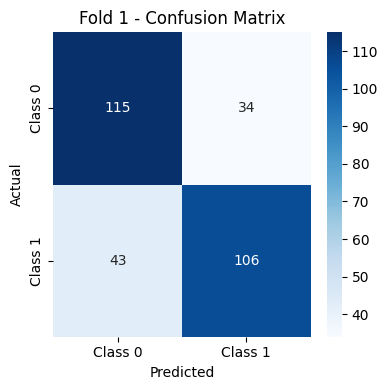

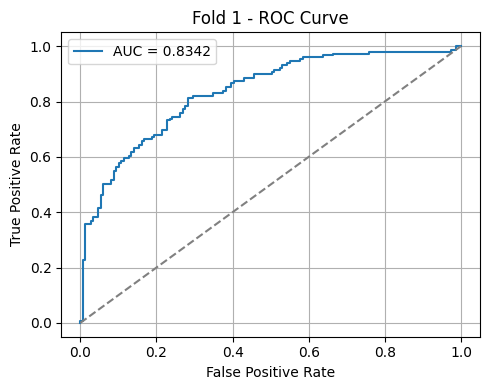

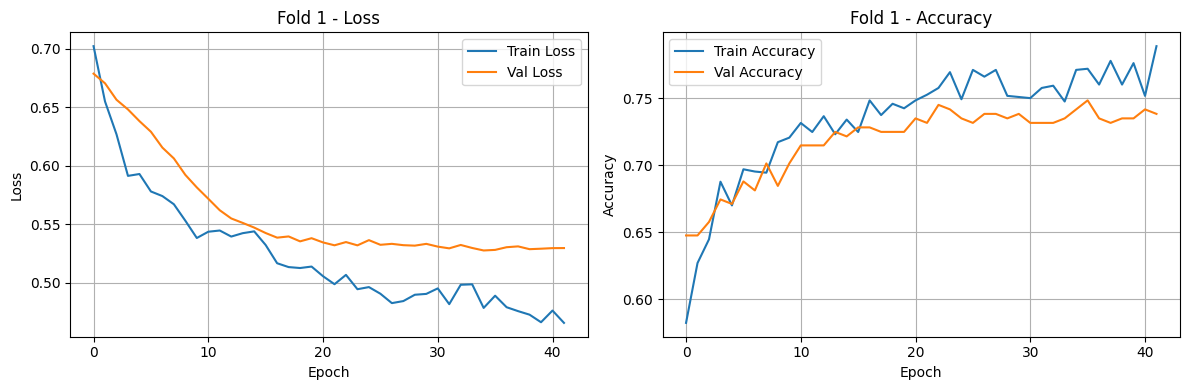


🔁 Fold 2/5 ----------------------------------------

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.72      0.68      0.70       149
         1.0       0.69      0.74      0.71       148

    accuracy                           0.71       297
   macro avg       0.71      0.71      0.71       297
weighted avg       0.71      0.71      0.71       297



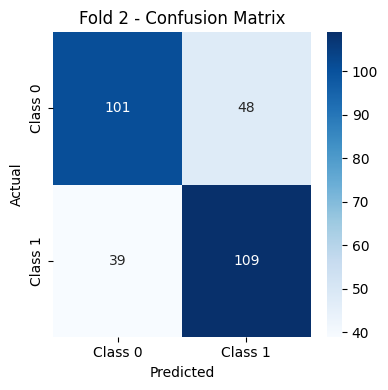

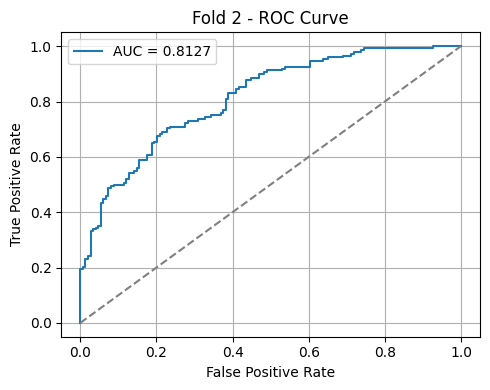

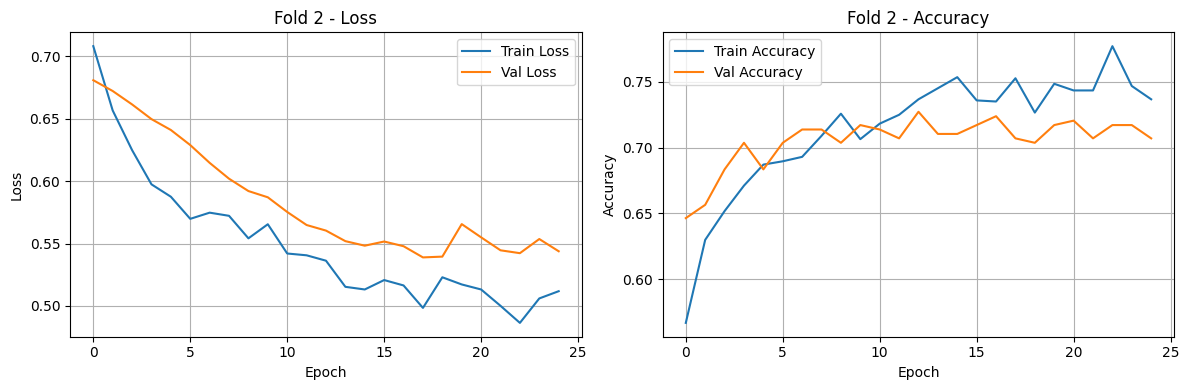


🔁 Fold 3/5 ----------------------------------------

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.75      0.77      0.75       149
         1.0       0.76      0.74      0.75       148

    accuracy                           0.75       297
   macro avg       0.75      0.75      0.75       297
weighted avg       0.75      0.75      0.75       297



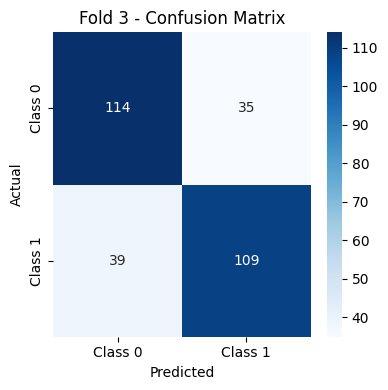

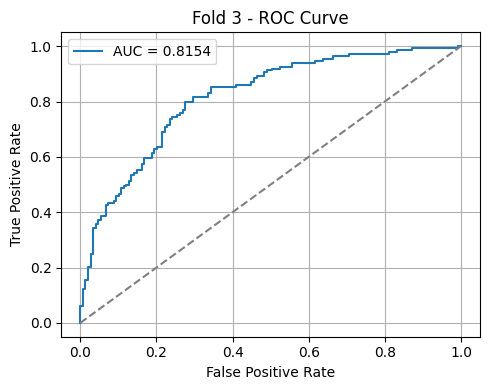

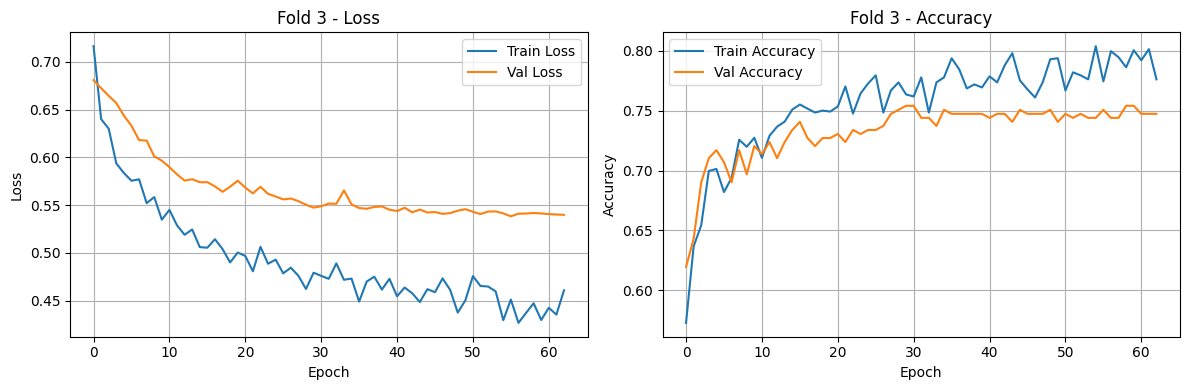


🔁 Fold 4/5 ----------------------------------------

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.77      0.81      0.79       148
         1.0       0.80      0.76      0.78       149

    accuracy                           0.78       297
   macro avg       0.79      0.78      0.78       297
weighted avg       0.79      0.78      0.78       297



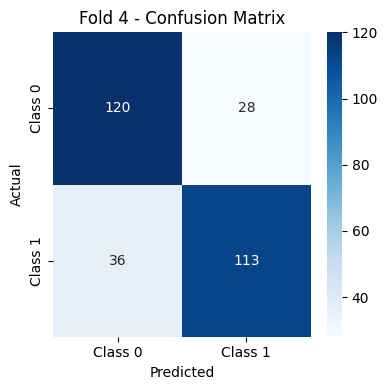

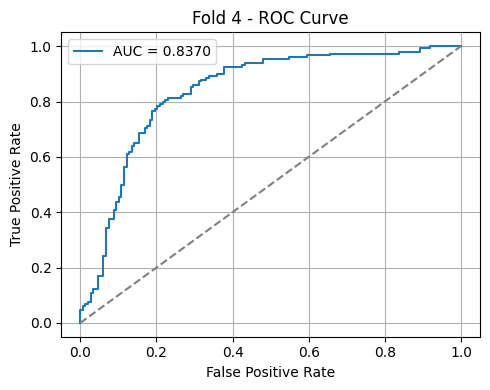

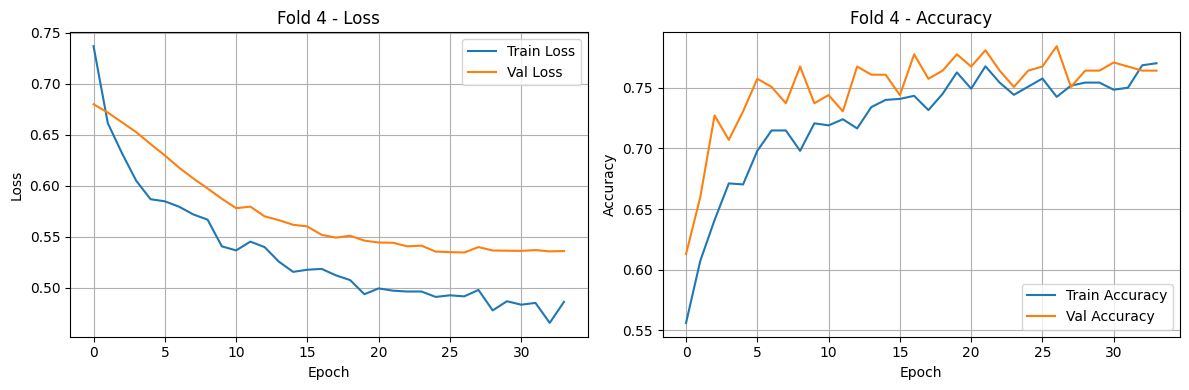


🔁 Fold 5/5 ----------------------------------------

📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.75      0.68      0.71       148
         1.0       0.71      0.77      0.74       149

    accuracy                           0.72       297
   macro avg       0.73      0.72      0.72       297
weighted avg       0.73      0.72      0.72       297



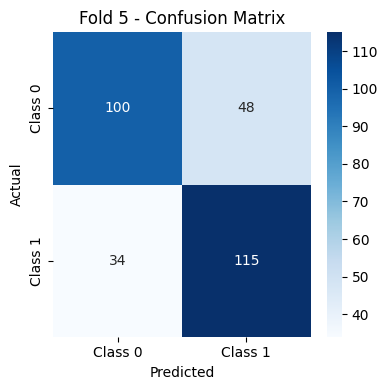

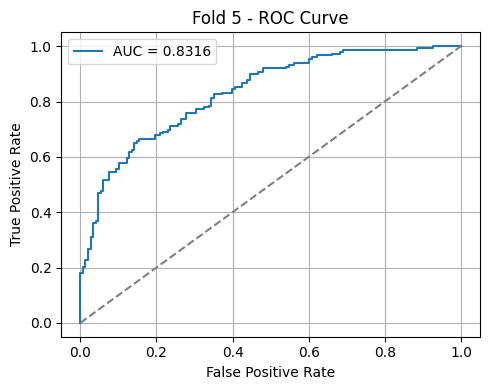

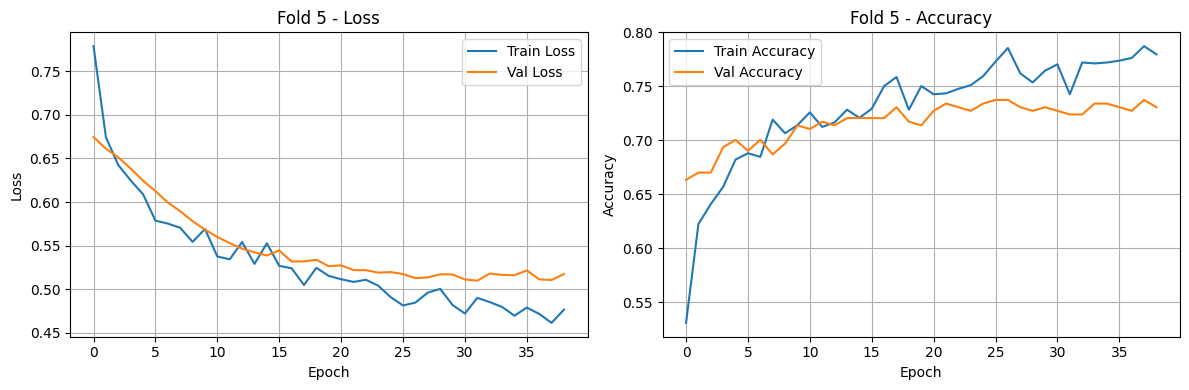

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model.layers[:-10]:
    layer.trainable = False
for layer in base_model.layers[-10:]:
    layer.trainable = True

feature_extractor = models.Model(inputs=base_model.input, outputs=base_model.output)

X_train_features, y_train_labels = [], []
for i, (images, labels) in enumerate(train_generator):
    images = preprocess_input(images)
    features = feature_extractor.predict(images, verbose=0)
    X_train_features.append(features)
    y_train_labels.append(labels)
    if i >= len(train_generator) - 1:
        break

X_train_features = np.vstack(X_train_features)
y_train_labels = np.hstack(y_train_labels)

X_flat = X_train_features.reshape(X_train_features.shape[0], -1)
X_resampled_flat, y_resampled = SMOTE(random_state=42).fit_resample(X_flat, y_train_labels)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled_flat)
X_resampled = X_scaled.reshape(-1, X_train_features.shape[1], X_train_features.shape[2], X_train_features.shape[3])
from sklearn.model_selection import StratifiedKFold
import seaborn as sns

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fold_no = 1

for train_idx, val_idx in skf.split(X_resampled, y_resampled):
    print(f"\n Fold {fold_no}/{n_splits} {'-'*40}")

    X_train, X_val = X_resampled[train_idx], X_resampled[val_idx]
    y_train, y_val = y_resampled[train_idx], y_resampled[val_idx]

    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(enumerate(class_weights))

    model = models.Sequential([
        layers.Input(shape=X_train.shape[1:]),
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.1),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss=BinaryCrossentropy(),
        metrics=['accuracy']
    )

    callbacks = [
        EarlyStopping(patience=7, monitor='val_loss', restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, verbose=0),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=0
    )

    y_pred = model.predict(X_val, verbose=0)
    y_pred_classes = (y_pred > 0.5).astype("int32").flatten()

    print("\n Classification Report:\n", classification_report(y_val, y_pred_classes))

    cm = confusion_matrix(y_val, y_pred_classes)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
    plt.title(f"Fold {fold_no} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    fpr, tpr, _ = roc_curve(y_val, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.title(f"Fold {fold_no} - ROC Curve")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Fold {fold_no} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'Fold {fold_no} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    fold_no += 1

In [ ]:
############ fusion #####

 25%|██▌       | 155/608 [01:12<03:28,  2.17it/s]

❌ مشکل در بارگذاری: /content/drive/MyDrive/train/malignant/p1 .jpg


100%|██████████| 608/608 [04:40<00:00,  2.16it/s]


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 245ms/step - accuracy: 0.3177 - loss: 2.4341 - val_accuracy: 0.5179 - val_loss: 1.6867 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4099 - loss: 2.1304 - val_accuracy: 0.6027 - val_loss: 1.4968 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5110 - loss: 1.8063 - val_accuracy: 0.6295 - val_loss: 1.3736 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5911 - loss: 1.5931 - val_accuracy: 0.6696 - val_loss: 1.2744 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6194 - loss: 1.5237 - val_accuracy: 0.7188 - val_loss: 1.1902 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6850 - loss: 1.3877 - val_accuracy: 0.7545 - val_loss: 1.1228 

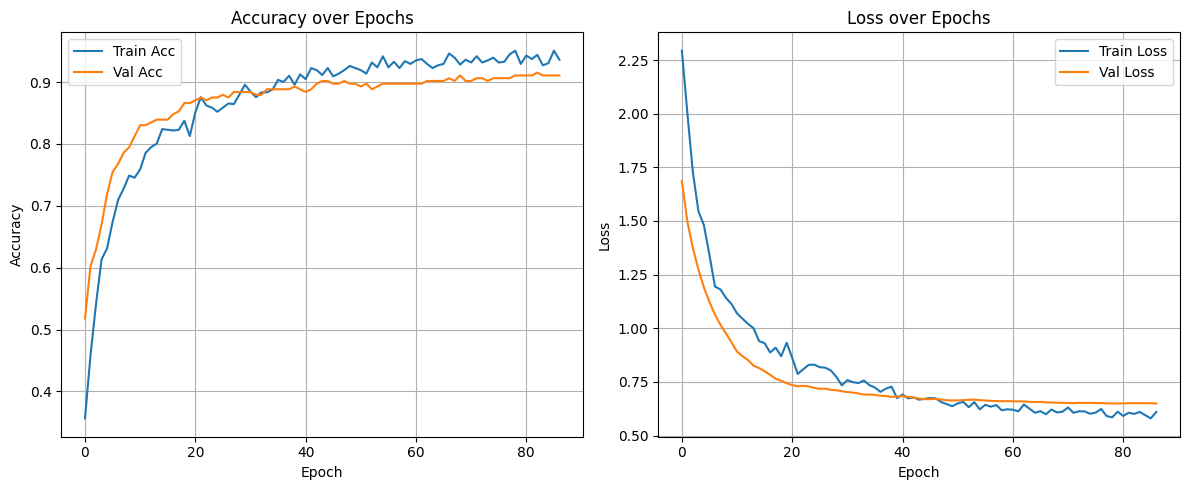

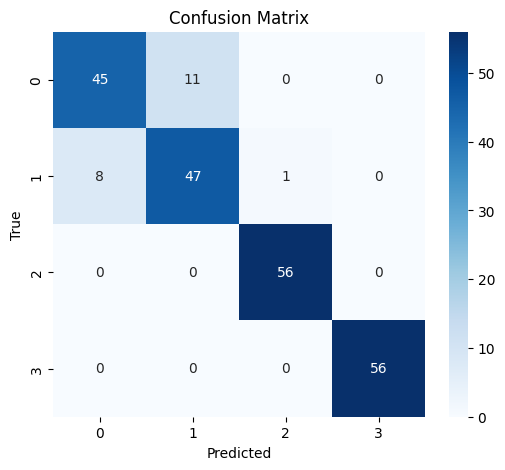

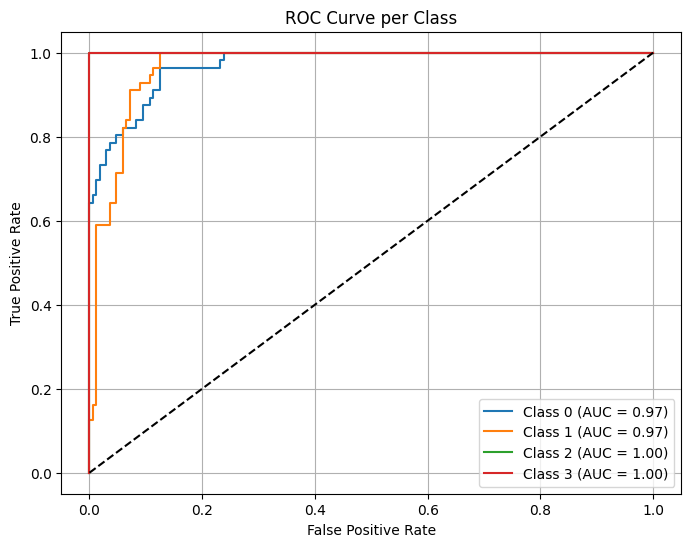

In [ ]:
import pandas as pd
import numpy as np
import os
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.concat([train_df, validation_df], ignore_index=True)
df = df[~df['malignancy_grade'].isna()]
df['malignancy_grade'] = df['malignancy_grade'].astype(int)

labels = to_categorical(df['malignancy_grade'].values, num_classes=4)

def load_and_preprocess_image(path):
    try:
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        return tf.keras.applications.xception.preprocess_input(img_array)
    except:
        print(f" مشکل در بارگذاری: {path}")
        return None

images = []
valid_indices = []

for i, path in enumerate(tqdm(df['image_path'].values)):
    img = load_and_preprocess_image(path)
    if img is not None:
        images.append(img)
        valid_indices.append(i)

images = np.array(images)
labels = labels[valid_indices]
df = df.iloc[valid_indices].reset_index(drop=True)

textual_features = ['gender', 'clark', 'breslow(mm)', 'ulceration', 'mitotic']
df['gender'] = LabelEncoder().fit_transform(df['gender'])

df[textual_features] = df[textual_features].fillna(0)
X_text = df[textual_features].values

scaler = StandardScaler()
X_text_scaled = scaler.fit_transform(X_text)

base_cnn = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
image_features = base_cnn.predict(images, verbose=1)
image_features = image_features.reshape(image_features.shape[0], -1)

X_combined = np.hstack([image_features, X_text_scaled])
y_raw = np.argmax(labels, axis=1)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_raw)
y_resampled_cat = to_categorical(y_resampled, num_classes=4)

X_img_resampled = X_resampled[:, :image_features.shape[1]].reshape(-1, 5, 5, 2048)
X_text_resampled = X_resampled[:, image_features.shape[1]:]

X_img_train, X_img_val, X_txt_train, X_txt_val, y_train, y_val = train_test_split(
    X_img_resampled, X_text_resampled, y_resampled_cat, test_size=0.2, stratify=y_resampled, random_state=42
)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_resampled), y=y_resampled)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

image_input = Input(shape=(5, 5, 2048))
x1 = layers.GlobalAveragePooling2D()(image_input)
x1 = layers.Dropout(0.3)(x1)
text_input = Input(shape=(X_txt_train.shape[1],))
x2 = layers.Dense(64, activation='relu')(text_input)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.3)(x2)
merged = layers.Concatenate()([x1, x2])
x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(4, activation='softmax')(x)
fusion_model = Model(inputs=[image_input, text_input], outputs=output)

fusion_model.compile(optimizer=Adam(learning_rate=3e-5),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, monitor='val_loss'),
    ModelCheckpoint('fusion_model_malignancy.keras', save_best_only=True, monitor='val_accuracy')
]

history = fusion_model.fit(
    [X_img_train, X_txt_train], y_train,
    validation_data=([X_img_val, X_txt_val], y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = fusion_model.evaluate([X_img_val, X_txt_val], y_val, verbose=0)
print(f"\n Validation Accuracy: {val_acc:.4f}")
print(f" Validation Loss: {val_loss:.4f}")

y_pred = fusion_model.predict([X_img_val, X_txt_val])
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_val, axis=1)

print("\n Classification Report:\n")
print(classification_report(y_true_labels, y_pred_labels))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
import seaborn as sns
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=range(4), yticklabels=range(4))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_val_bin = label_binarize(y_true_labels, classes=[0, 1, 2, 3])
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(4):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(4):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve per Class')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

Model: "Fusion_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 5, 5,      │          0 │ -                 │
│ (InputLayer)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │        320 │ text_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ image_input[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_6[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 2112)      │          0 │ dropout_9[0][0],  │
│ (Concatenate)       │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 256)       │    540,928 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 256)       │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 4)         │      1,028 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 543,556 (2.07 MB)

 Trainable params: 542,916 (2.07 MB)

 Non-trainable params: 640 (2.50 KB)

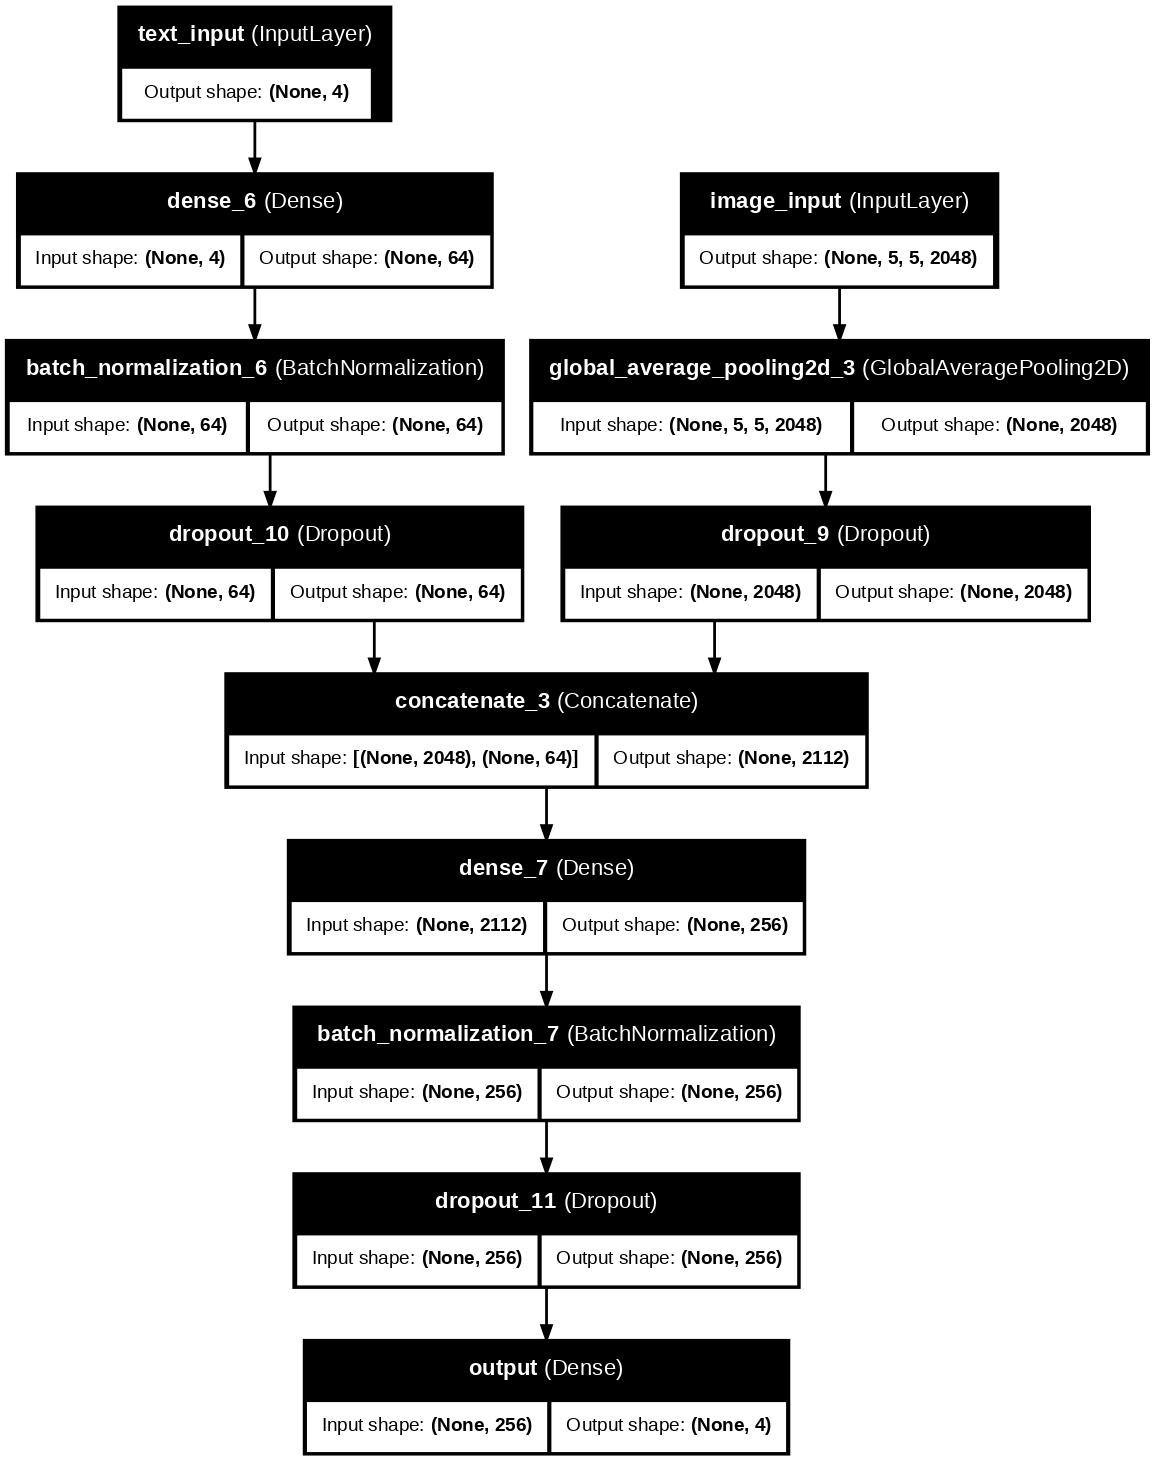

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models, Input, Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import plot_model

image_input = Input(shape=(5, 5, 2048), name='image_input')
x1 = layers.GlobalAveragePooling2D()(image_input)
x1 = layers.Dropout(0.3)(x1)
text_input = Input(shape=(4,), name='text_input')
x2 = layers.Dense(64, activation='relu')(text_input)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.3)(x2)
merged = layers.Concatenate()([x1, x2])
x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(4, activation='softmax', name='output')(x)

fusion_model = Model(inputs=[image_input, text_input], outputs=output, name='Fusion_Model')

fusion_model.summary()
plot_model(fusion_model,
           to_file='fusion_model_architecture.png',
           show_shapes=True,
           show_layer_names=True,
           expand_nested=True,
           dpi=100)


--- Fold 1/5 ---
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.3133 - loss: 2.4587 - val_accuracy: 0.4420 - val_loss: 1.7366 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3766 - loss: 2.1397 - val_accuracy: 0.5491 - val_loss: 1.4991 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5049 - loss: 1.7720 - val_accuracy: 0.6518 - val_loss: 1.3327 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5327 - loss: 1.7728 - val_accuracy: 0.7009 - val_loss: 1.2268 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6342 - loss: 1.4003 - val_accuracy: 0.7188 - val_loss: 1.1482 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6530 - loss: 1.3920 - val_accuracy: 0.7321 - val_loss: 1.0840 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11m

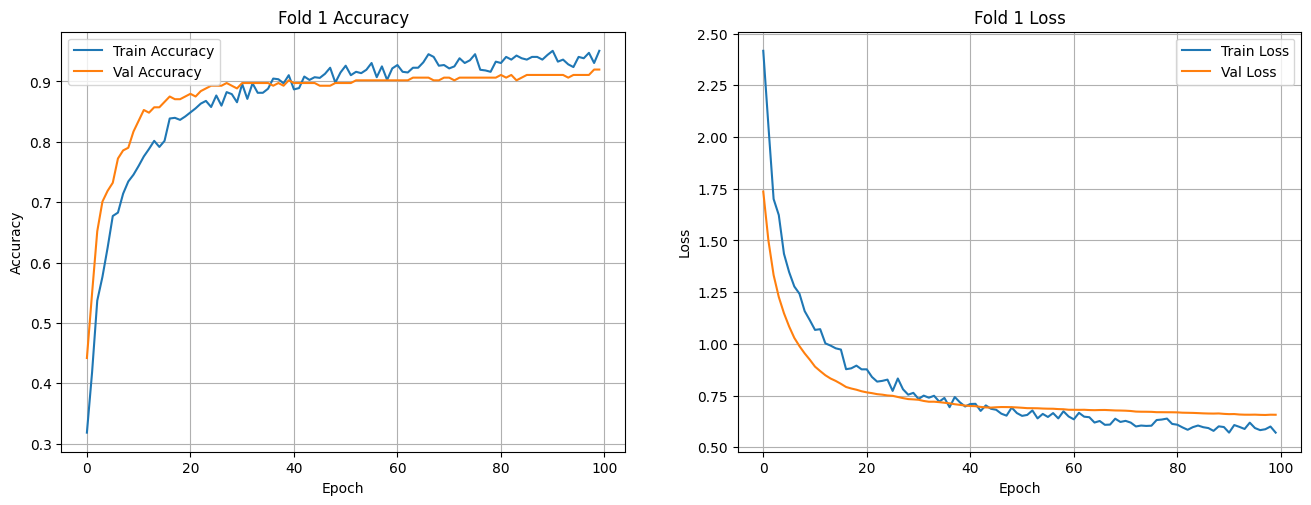

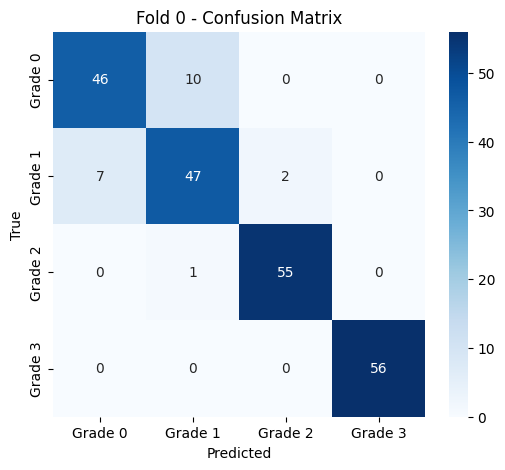

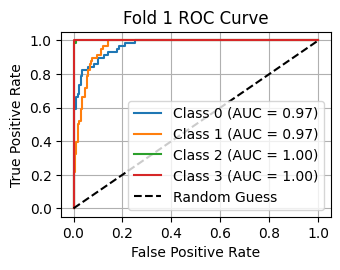


--- Fold 2/5 ---
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - accuracy: 0.3027 - loss: 2.4973 - val_accuracy: 0.5291 - val_loss: 1.6421 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4188 - loss: 2.1058 - val_accuracy: 0.6054 - val_loss: 1.4634 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5392 - loss: 1.7197 - val_accuracy: 0.6771 - val_loss: 1.3245 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5793 - loss: 1.6290 - val_accuracy: 0.7175 - val_loss: 1.2221 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6178 - loss: 1.5591 - val_accuracy: 0.7534 - val_loss: 1.1377 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6741 - loss: 1.3919 - val_accuracy: 0.7803 - val_loss: 1.0671 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11

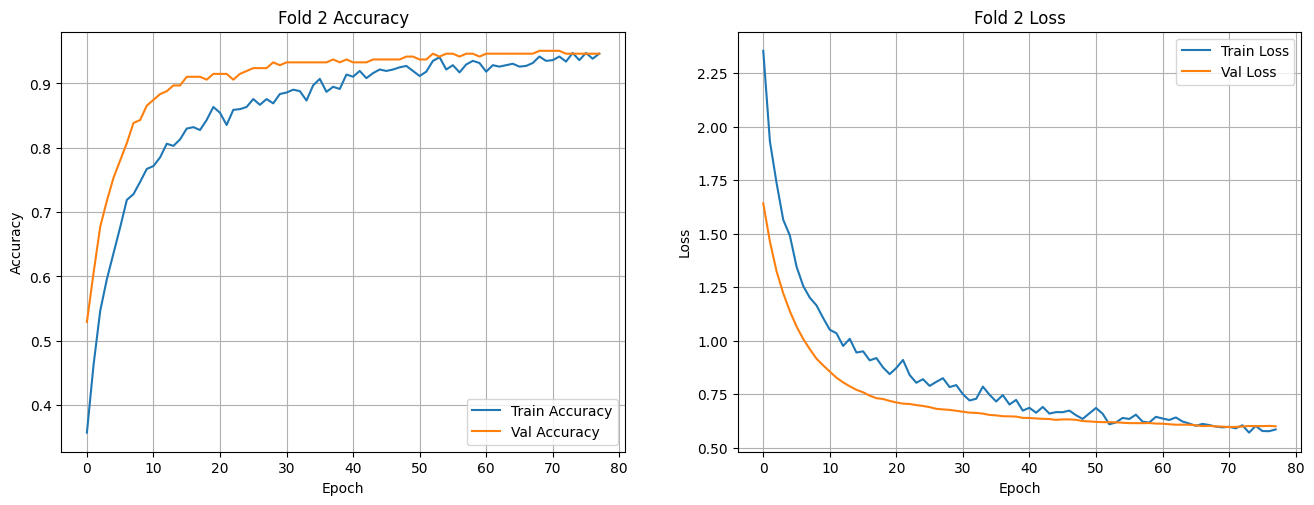

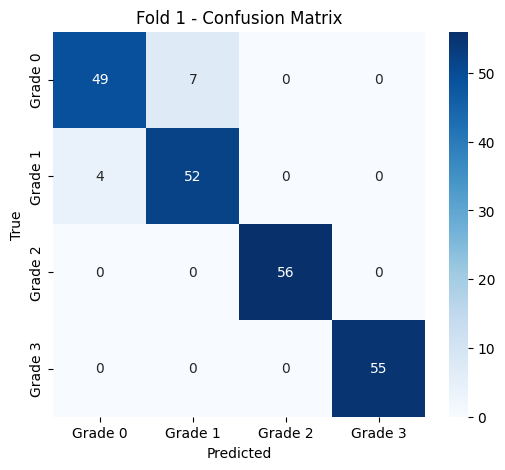

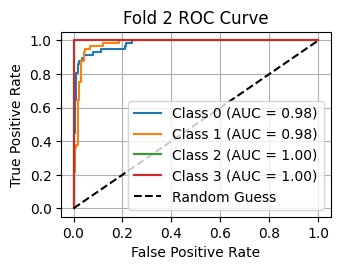


--- Fold 3/5 ---
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.2651 - loss: 2.7660 - val_accuracy: 0.2152 - val_loss: 2.1078 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4014 - loss: 2.1408 - val_accuracy: 0.3722 - val_loss: 1.6990 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4832 - loss: 1.8911 - val_accuracy: 0.5919 - val_loss: 1.4436 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5460 - loss: 1.6156 - val_accuracy: 0.6951 - val_loss: 1.2807 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6099 - loss: 1.4300 - val_accuracy: 0.7489 - val_loss: 1.1651 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6279 - loss: 1.3444 - val_accuracy: 0.7982 - val_loss: 1.0817 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12m

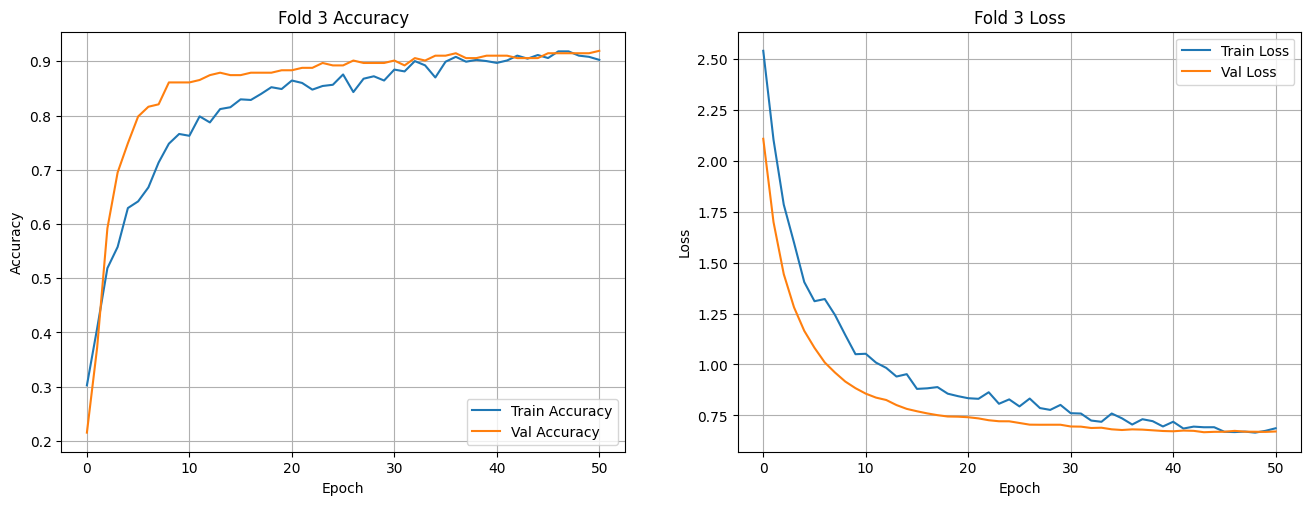

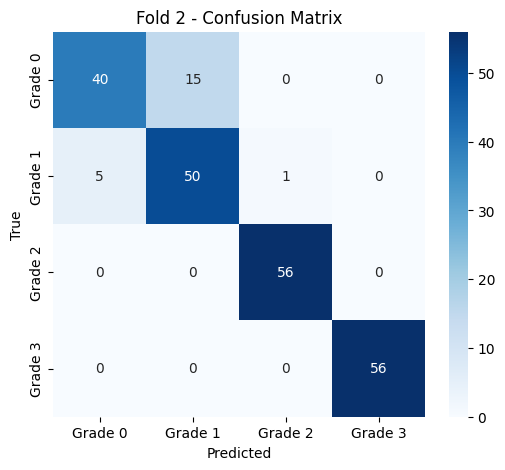

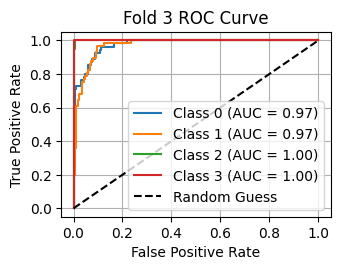


--- Fold 4/5 ---
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.2450 - loss: 2.8049 - val_accuracy: 0.3767 - val_loss: 1.7850 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3579 - loss: 2.1655 - val_accuracy: 0.5650 - val_loss: 1.5818 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5236 - loss: 1.7842 - val_accuracy: 0.6143 - val_loss: 1.4338 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5639 - loss: 1.6251 - val_accuracy: 0.6726 - val_loss: 1.3113 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5888 - loss: 1.5257 - val_accuracy: 0.7220 - val_loss: 1.2096 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6424 - loss: 1.3712 - val_accuracy: 0.7534 - val_loss: 1.1304 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 18m

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Fold 4 Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82        56
           1       0.78      0.93      0.85        55
           2       1.00      1.00      1.00        56
           3       1.00      1.00      1.00        56

    accuracy                           0.92       223
   macro avg       0.92      0.92      0.92       223
weighted avg       0.93      0.92      0.92       223



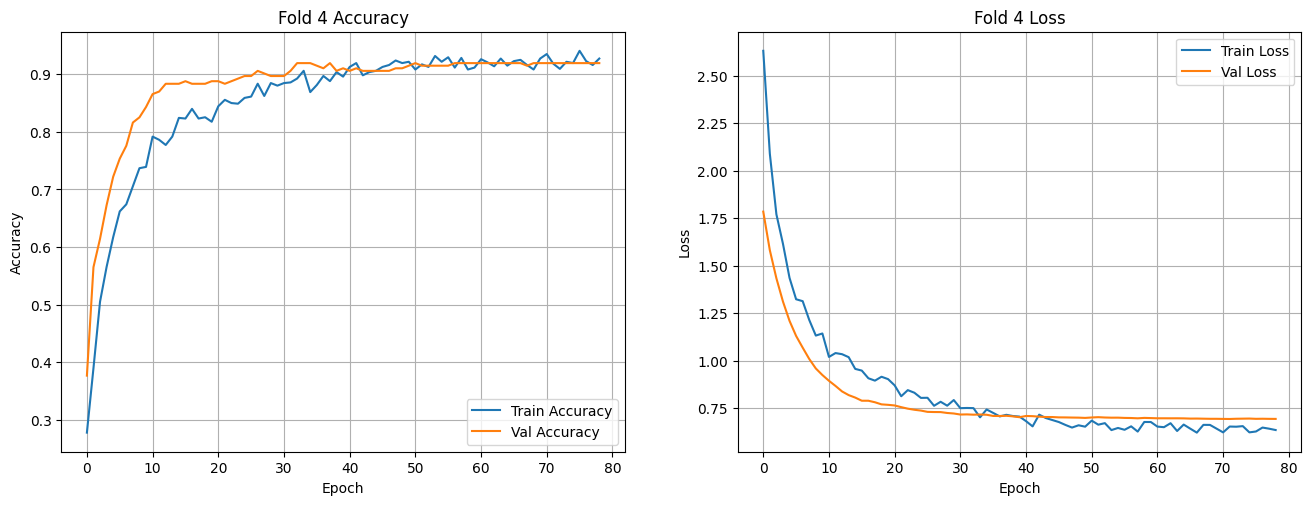

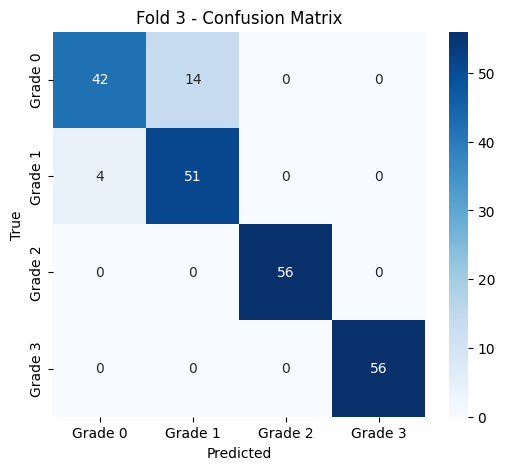

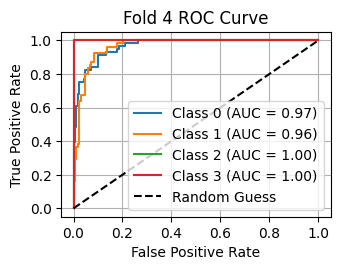


--- Fold 5/5 ---
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 119ms/step - accuracy: 0.3766 - loss: 2.3237 - val_accuracy: 0.4664 - val_loss: 1.6512 - learning_rate: 3.0000e-05
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.4296 - loss: 2.0384 - val_accuracy: 0.5561 - val_loss: 1.4816 - learning_rate: 3.0000e-05
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5200 - loss: 1.7756 - val_accuracy: 0.6726 - val_loss: 1.3355 - learning_rate: 3.0000e-05
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5787 - loss: 1.6206 - val_accuracy: 0.7130 - val_loss: 1.2258 - learning_rate: 3.0000e-05
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6217 - loss: 1.4321 - val_accuracy: 0.7309 - val_loss: 1.1407 - learning_rate: 3.0000e-05
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6819 - loss: 1.3181 - val_accuracy: 0.7668 - val_loss: 1.0789 - learning_rate: 3.0000e-05
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11m

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
Fold 5 Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.73      0.74        56
           1       0.74      0.75      0.74        56
           2       1.00      1.00      1.00        55
           3       1.00      1.00      1.00        56

    accuracy                           0.87       223
   macro avg       0.87      0.87      0.87       223
weighted avg       0.87      0.87      0.87       223



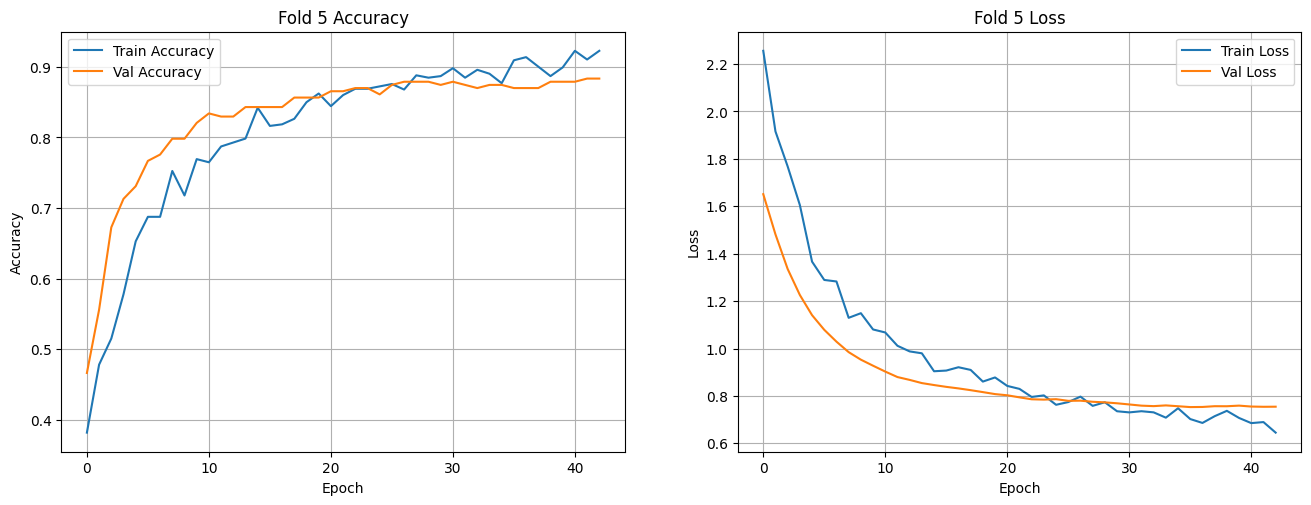

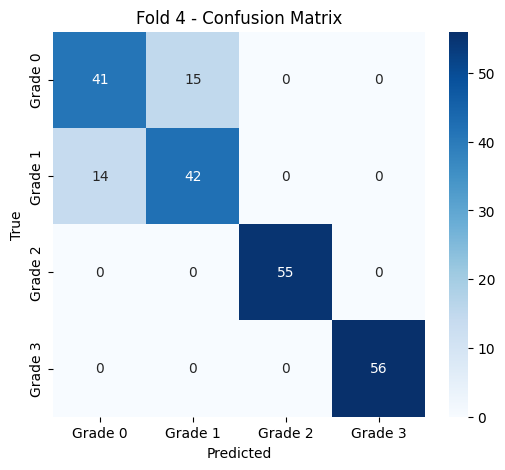

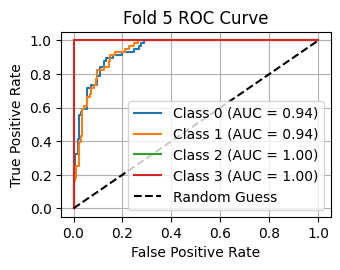

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras import layers, Input, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.preprocessing import label_binarize

n_splits = 5

val_accuracies = []
val_losses = []
histories = []
reports = []

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_resampled, y_resampled)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")

    X_img_train_fold = X_resampled[train_idx, :image_features.shape[1]].reshape(-1, 5,5,2048)
    X_txt_train_fold = X_resampled[train_idx, image_features.shape[1]:]
    y_train_fold = to_categorical(y_resampled[train_idx], num_classes=4)

    X_img_val_fold = X_resampled[val_idx, :image_features.shape[1]].reshape(-1, 5,5,2048)
    X_txt_val_fold = X_resampled[val_idx, image_features.shape[1]:]
    y_val_fold = to_categorical(y_resampled[val_idx], num_classes=4)

    class_weights_fold = compute_class_weight(class_weight='balanced', classes=np.unique(y_resampled[train_idx]), y=y_resampled[train_idx])
    class_weights_dict_fold = {i: w for i, w in enumerate(class_weights_fold)}

    image_input = Input(shape=(5,5,2048))
    x1 = layers.GlobalAveragePooling2D()(image_input)
    x1 = layers.Dropout(0.3)(x1)

    text_input = Input(shape=(X_txt_train_fold.shape[1],))
    x2 = layers.Dense(64, activation='relu')(text_input)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Dropout(0.3)(x2)

    merged = layers.Concatenate()([x1, x2])
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(4, activation='softmax')(x)

    model = Model(inputs=[image_input, text_input], outputs=output)

    model.compile(optimizer=Adam(learning_rate=3e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    callbacks = [
        EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, monitor='val_loss'),
        ModelCheckpoint(f'fusion_model_malignancy_fold{fold+1}.keras', save_best_only=True, monitor='val_accuracy')
    ]

    history = model.fit(
        [X_img_train_fold, X_txt_train_fold], y_train_fold,
        validation_data=([X_img_val_fold, X_txt_val_fold], y_val_fold),
        epochs=100,
        batch_size=32,
        class_weight=class_weights_dict_fold,
        callbacks=callbacks,
        verbose=1
    )
    histories.append(history)

    val_loss, val_acc = model.evaluate([X_img_val_fold, X_txt_val_fold], y_val_fold, verbose=0)
    val_accuracies.append(val_acc)
    val_losses.append(val_loss)
    print(f"Fold {fold+1} Validation Accuracy: {val_acc:.4f}")
    print(f"Fold {fold+1} Validation Loss: {val_loss:.4f}")

    y_pred_prob = model.predict([X_img_val_fold, X_txt_val_fold])
    y_pred_labels = np.argmax(y_pred_prob, axis=1)
    y_true_labels = np.argmax(y_val_fold, axis=1)

    from sklearn.metrics import classification_report
    report = classification_report(y_true_labels, y_pred_labels, output_dict=True)
    reports.append(report)
    print(f"Fold {fold+1} Classification Report:")
    print(classification_report(y_true_labels, y_pred_labels))

    plt.figure(figsize=(16, 12))

    plt.subplot(2, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'Fold {fold+1} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.subplot(2, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'Fold {fold+1} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    N_CLASSES = 4
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f'Grade {i}' for i in range(N_CLASSES)],
                yticklabels=[f'Grade {i}' for i in range(N_CLASSES)])
    plt.title(f'Fold {fold} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    y_val_bin = label_binarize(y_true_labels, classes=[0, 1, 2, 3])
    N_CLASSES = 4

    plt.subplot(2, 2, 4)
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(N_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.title(f'Fold {fold+1} ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.concat([train_df, validation_df], ignore_index=True)
df = df[~df['diagnosis'].isna()]
df['diagnosis'] = df['diagnosis'].astype(int)

labels = to_categorical(df['diagnosis'].values, num_classes=2)

def load_and_preprocess_image(path):
    try:
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        return tf.keras.applications.xception.preprocess_input(img_array)
    except:
        print(f" مشکل در بارگذاری: {path}")
        return None

images = []
valid_indices = []

for i, path in enumerate(tqdm(df['image_path'].values)):
    img = load_and_preprocess_image(path)
    if img is not None:
        images.append(img)
        valid_indices.append(i)

images = np.array(images)
labels = labels[valid_indices]
df = df.iloc[valid_indices].reset_index(drop=True)

textual_features = ['gender', 'clark', 'breslow(mm)', 'ulceration', 'mitotic']
df['gender'] = LabelEncoder().fit_transform(df['gender'])
df[textual_features] = df[textual_features].fillna(0)
X_text = df[textual_features].values

scaler = StandardScaler()
X_text_scaled = scaler.fit_transform(X_text)

base_cnn = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
image_features = base_cnn.predict(images, verbose=1)
image_features = image_features.reshape(image_features.shape[0], -1)

X_combined = np.hstack([image_features, X_text_scaled])
y_raw = np.argmax(labels, axis=1)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_combined, y_raw)
y_resampled_cat = to_categorical(y_resampled, num_classes=2)

X_img_resampled = X_resampled[:, :image_features.shape[1]].reshape(-1, 5,5,2048)
X_text_resampled = X_resampled[:, image_features.shape[1]:]

X_img_train, X_img_val, X_txt_train, X_txt_val, y_train, y_val = train_test_split(
    X_img_resampled, X_text_resampled, y_resampled_cat, test_size=0.2, stratify=y_resampled, random_state=42
)

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_resampled), y=y_resampled)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}

image_input = Input(shape=(5,5,2048))
x1 = layers.GlobalAveragePooling2D()(image_input)
x1 = layers.Dropout(0.3)(x1)
text_input = Input(shape=(X_txt_train.shape[1],))
x2 = layers.Dense(64, activation='relu')(text_input)
x2 = layers.BatchNormalization()(x2)
x2 = layers.Dropout(0.3)(x2)
merged = layers.Concatenate()([x1, x2])
x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
output = layers.Dense(2, activation='softmax')(x)

fusion_model = Model(inputs=[image_input, text_input], outputs=output)

fusion_model.compile(optimizer=Adam(learning_rate=3e-5),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

callbacks = [
    EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, monitor='val_loss'),
    ModelCheckpoint('fusion_model_diagnosis.keras', save_best_only=True, monitor='val_accuracy')
]

history = fusion_model.fit(
    [X_img_train, X_txt_train], y_train,
    validation_data=([X_img_val, X_txt_val], y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

val_loss, val_acc = fusion_model.evaluate([X_img_val, X_txt_val], y_val, verbose=0)
print(f"\n Validation Accuracy: {val_acc:.4f}")
print(f" Validation Loss: {val_loss:.4f}")

y_pred = fusion_model.predict([X_img_val, X_txt_val])
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_val, axis=1)

print("\n Classification Report:\n")
print(classification_report(y_true_labels, y_pred_labels))

 28%|██▊       | 172/608 [00:02<00:04, 91.68it/s]

❌ مشکل در بارگذاری: /content/drive/MyDrive/train/malignant/p1 .jpg


100%|██████████| 608/608 [00:06<00:00, 93.47it/s]


19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 359ms/step
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step - accuracy: 0.4879 - loss: 1.7389 - val_accuracy: 0.5606 - val_loss: 1.1139 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5497 - loss: 1.5075 - val_accuracy: 0.6591 - val_loss: 1.0509 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6170 - loss: 1.3685 - val_accuracy: 0.6742 - val_loss: 1.0088 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6479 - loss: 1.2061 - val_accuracy: 0.6970 - val_loss: 0.9799 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6473 - loss: 1.2268 - val_accuracy: 0.7121 - val_loss: 0.9620 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7136 - loss: 1.1543 - val_accuracy: 0.7121 - val_loss: 0.9409 - learning_rate: 3.0000e-05
Epoch 7/100
17/17 ━━

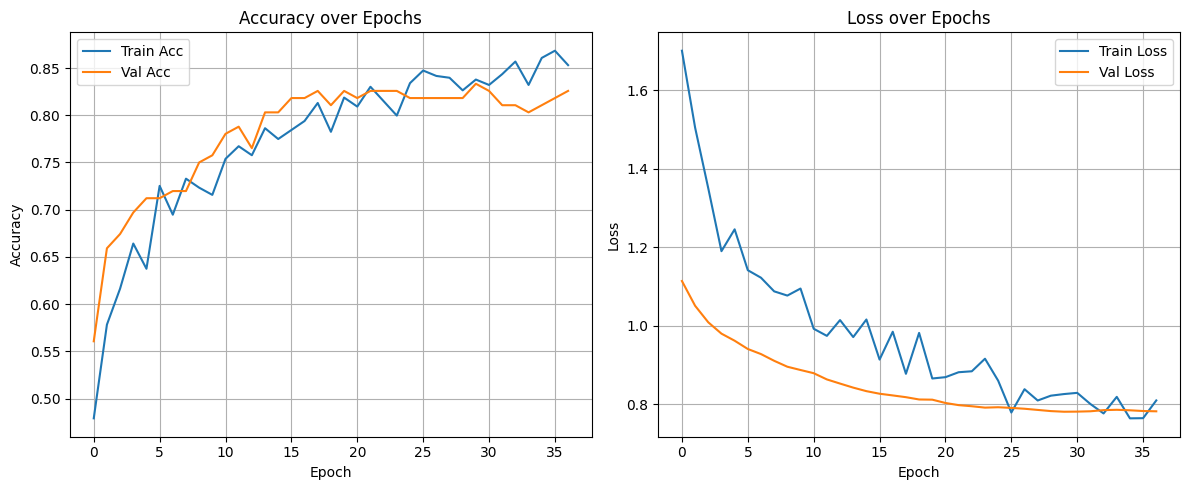

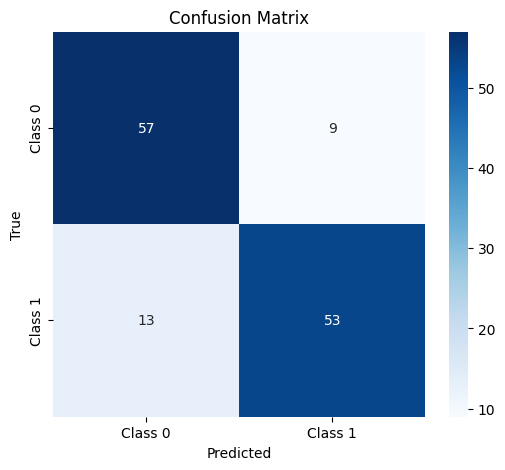

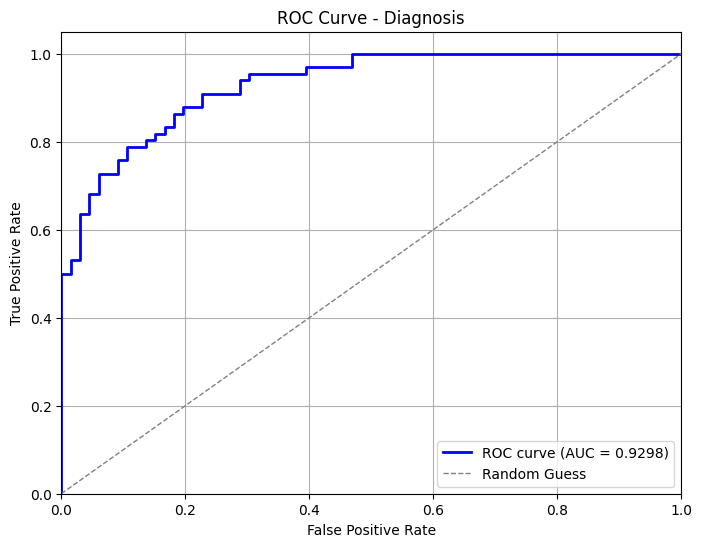

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

conf_mat = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

y_true = y_val[:, 1]
y_scores = y_pred[:, 1]

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Diagnosis')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

 27%|██▋       | 167/608 [00:02<00:04, 90.22it/s]

❌ مشکل در بارگذاری: /content/drive/MyDrive/train/malignant/p1 .jpg


100%|██████████| 608/608 [00:06<00:00, 92.15it/s]


19/19 ━━━━━━━━━━━━━━━━━━━━ 13s 353ms/step

--- Fold 1 ---
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 218ms/step - accuracy: 0.5219 - loss: 1.6644 - val_accuracy: 0.5820 - val_loss: 1.2578 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5341 - loss: 1.5919 - val_accuracy: 0.6230 - val_loss: 1.1599 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6559 - loss: 1.2746 - val_accuracy: 0.6557 - val_loss: 1.0574 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6284 - loss: 1.2603 - val_accuracy: 0.7295 - val_loss: 0.9942 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6315 - loss: 1.3352 - val_accuracy: 0.7459 - val_loss: 0.9653 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6577 - loss: 1.1912 - val_accuracy: 0.7377 - val_loss: 0.9521 - learning_rate: 3.0000e-05
Epoch

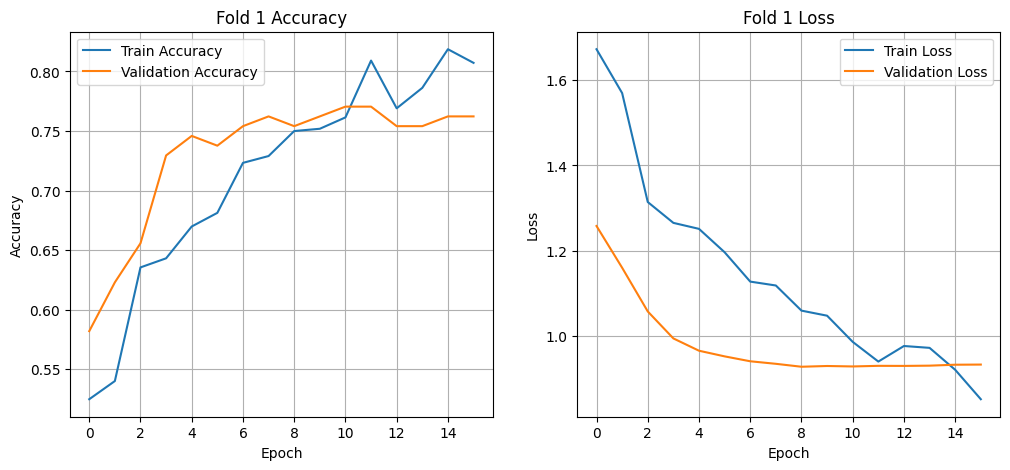

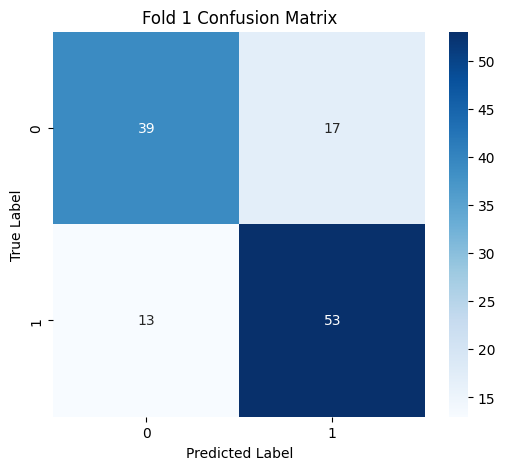

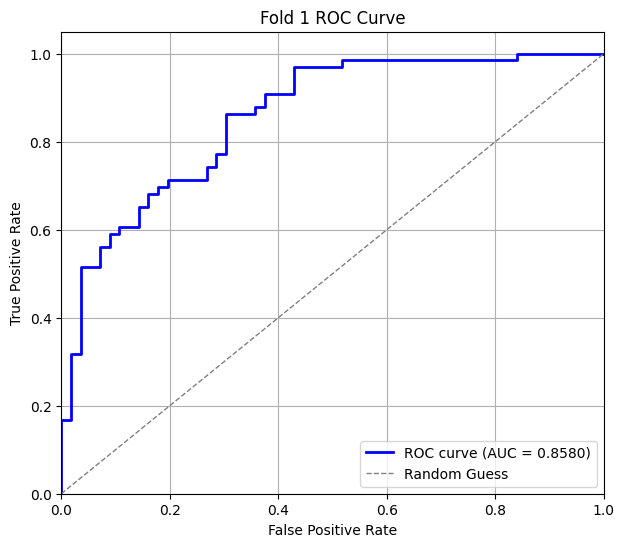


--- Fold 2 ---
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step - accuracy: 0.4578 - loss: 1.9103 - val_accuracy: 0.5410 - val_loss: 1.1978 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5087 - loss: 1.7395 - val_accuracy: 0.6803 - val_loss: 1.0639 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6207 - loss: 1.4784 - val_accuracy: 0.7131 - val_loss: 0.9868 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6008 - loss: 1.3482 - val_accuracy: 0.7623 - val_loss: 0.9482 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6306 - loss: 1.3447 - val_accuracy: 0.7623 - val_loss: 0.9315 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6455 - loss: 1.3661 - val_accuracy: 0.7623 - val_loss: 0.9233 - learning_rate: 3.0000e-05
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/

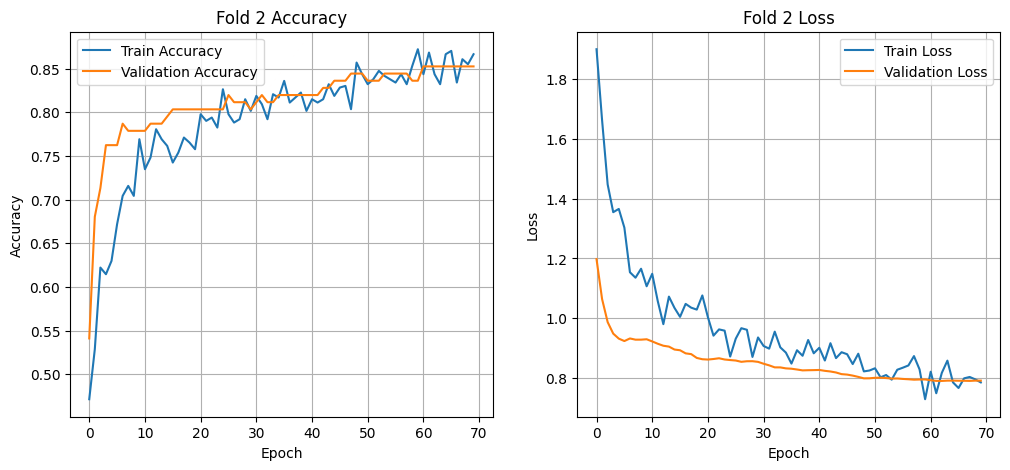

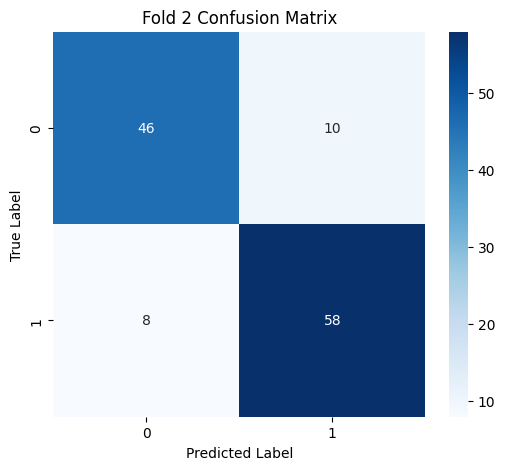

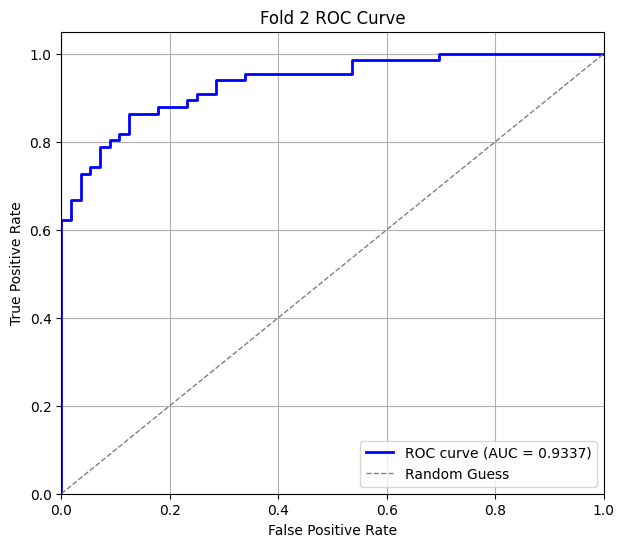


--- Fold 3 ---
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 203ms/step - accuracy: 0.4866 - loss: 1.7723 - val_accuracy: 0.4876 - val_loss: 1.2215 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5446 - loss: 1.6216 - val_accuracy: 0.5868 - val_loss: 1.1241 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6412 - loss: 1.3088 - val_accuracy: 0.6694 - val_loss: 1.0701 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6540 - loss: 1.2428 - val_accuracy: 0.6860 - val_loss: 1.0362 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6685 - loss: 1.1851 - val_accuracy: 0.7190 - val_loss: 1.0065 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6813 - loss: 1.1994 - val_accuracy: 0.7355 - val_loss: 0.9884 - learning_rate: 3.0000e-05
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/

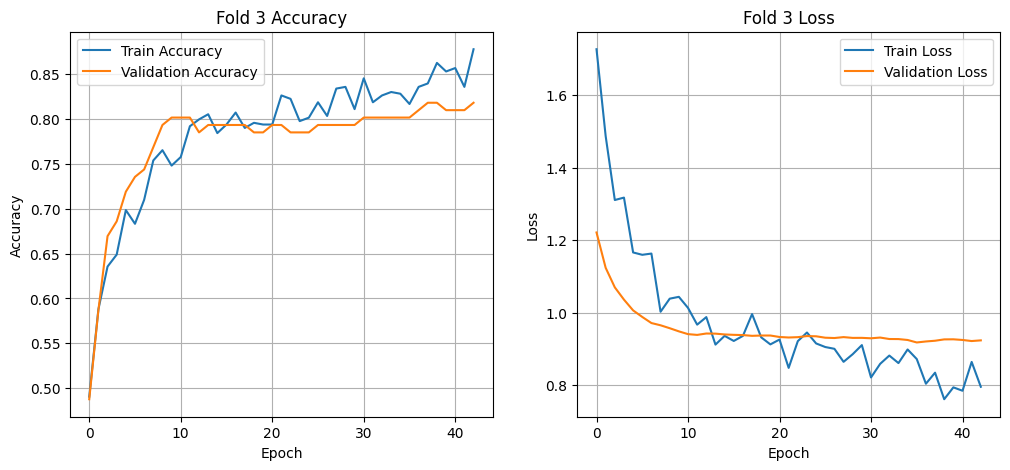

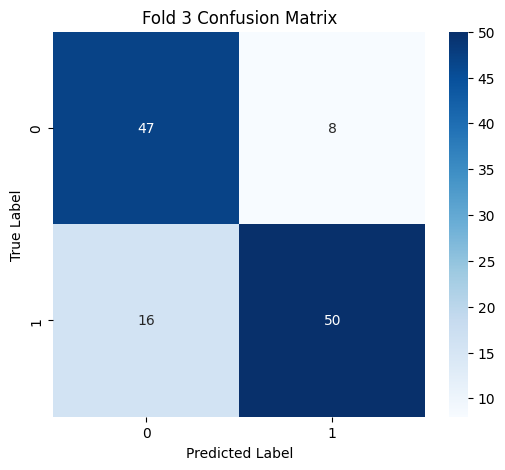

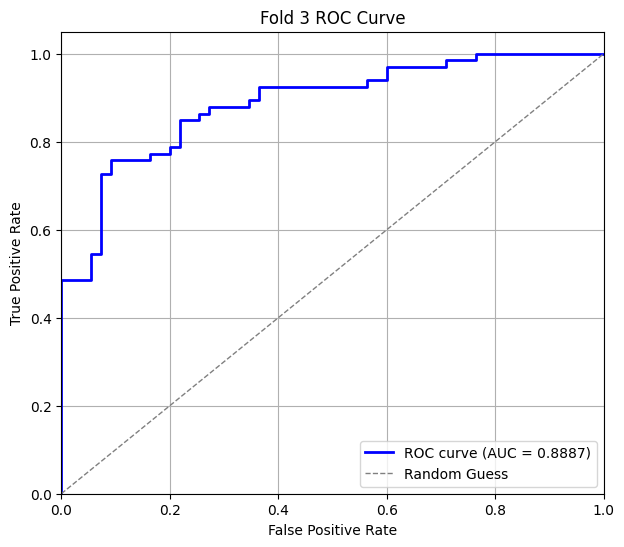


--- Fold 4 ---
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 319ms/step - accuracy: 0.5148 - loss: 1.5798 - val_accuracy: 0.5455 - val_loss: 1.1808 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6101 - loss: 1.3815 - val_accuracy: 0.6281 - val_loss: 1.1130 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6496 - loss: 1.2075 - val_accuracy: 0.6364 - val_loss: 1.0788 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6753 - loss: 1.2401 - val_accuracy: 0.6612 - val_loss: 1.0606 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6993 - loss: 1.0872 - val_accuracy: 0.6777 - val_loss: 1.0518 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7185 - loss: 1.1461 - val_accuracy: 0.7190 - val_loss: 1.0302 - learning_rate: 3.0000e-05
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/

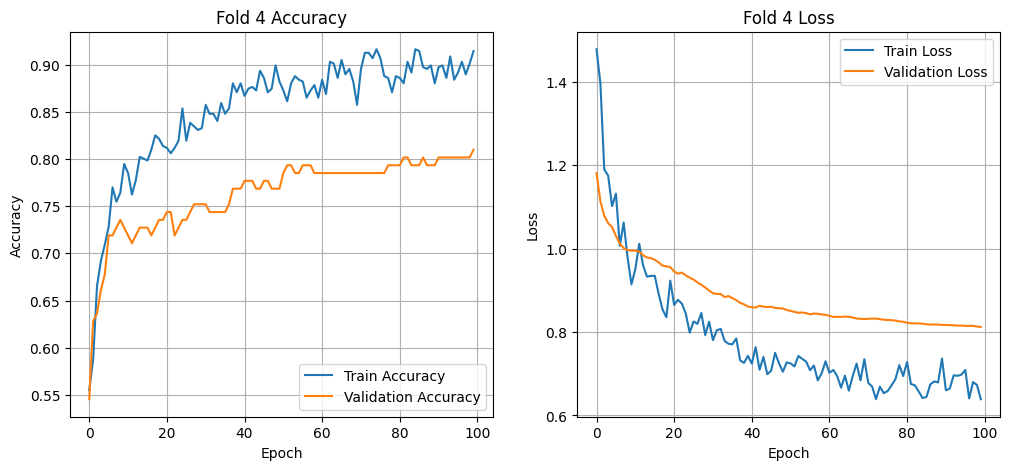

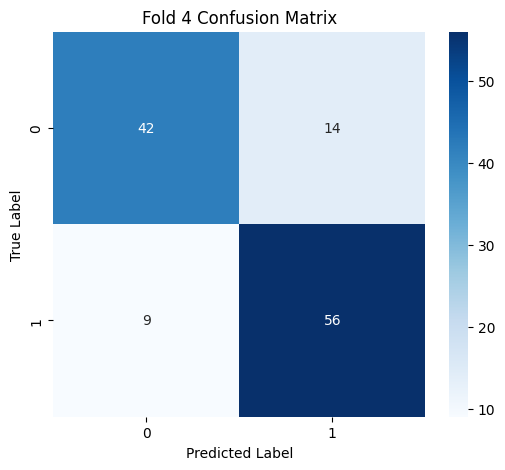

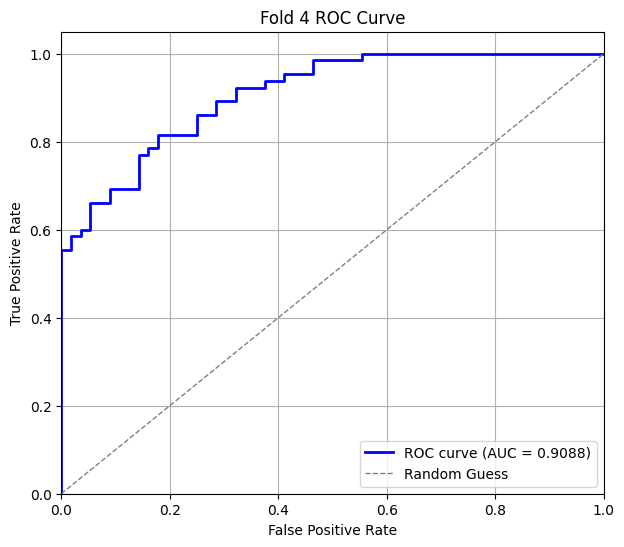


--- Fold 5 ---
Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 185ms/step - accuracy: 0.5783 - loss: 1.4528 - val_accuracy: 0.6694 - val_loss: 1.0830 - learning_rate: 3.0000e-05
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5817 - loss: 1.4028 - val_accuracy: 0.6860 - val_loss: 1.0244 - learning_rate: 3.0000e-05
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6535 - loss: 1.3104 - val_accuracy: 0.7025 - val_loss: 0.9880 - learning_rate: 3.0000e-05
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6449 - loss: 1.2668 - val_accuracy: 0.7355 - val_loss: 0.9611 - learning_rate: 3.0000e-05
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6928 - loss: 1.1685 - val_accuracy: 0.7355 - val_loss: 0.9367 - learning_rate: 3.0000e-05
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7510 - loss: 1.1706 - val_accuracy: 0.7603 - val_loss: 0.9223 - learning_rate: 3.0000e-05
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/

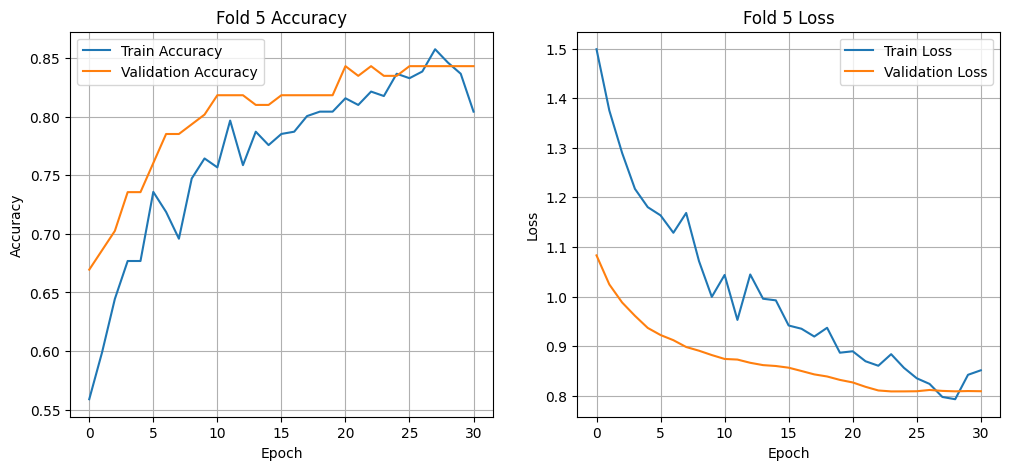

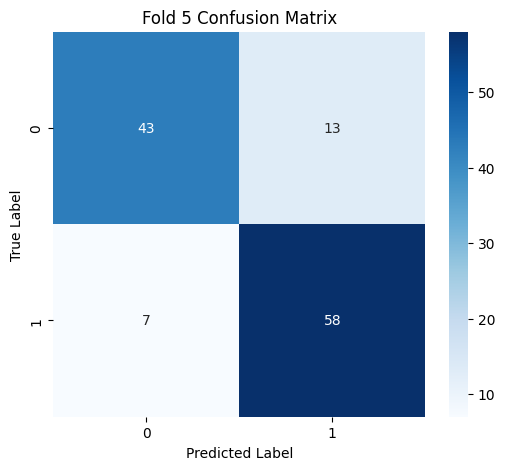

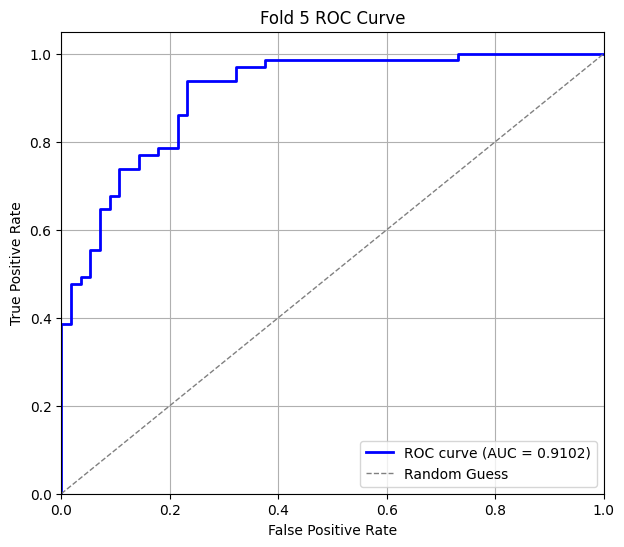

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tqdm import tqdm
import tensorflow as tf
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.concat([train_df, validation_df], ignore_index=True)
df = df[~df['diagnosis'].isna()]
df['diagnosis'] = df['diagnosis'].astype(int)

labels = to_categorical(df['diagnosis'].values, num_classes=2)

def load_and_preprocess_image(path):
    try:
        img = load_img(path, target_size=(224, 224))
        img_array = img_to_array(img)
        return tf.keras.applications.xception.preprocess_input(img_array)
    except:
        print(f" مشکل در بارگذاری: {path}")
        return None

images = []
valid_indices = []

for i, path in enumerate(tqdm(df['image_path'].values)):
    img = load_and_preprocess_image(path)
    if img is not None:
        images.append(img)
        valid_indices.append(i)

images = np.array(images)
labels = labels[valid_indices]
df = df.iloc[valid_indices].reset_index(drop=True)

textual_features = ['gender', 'clark', 'breslow(mm)', 'ulceration', 'mitotic']
df['gender'] = LabelEncoder().fit_transform(df['gender'])
df[textual_features] = df[textual_features].fillna(0)
X_text = df[textual_features].values
scaler = StandardScaler()
X_text_scaled = scaler.fit_transform(X_text)

base_cnn = InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
image_features = base_cnn.predict(images, verbose=1)
image_features = image_features.reshape(image_features.shape[0], -1)

X_combined = np.hstack([image_features, X_text_scaled])
y_raw = np.argmax(labels, axis=1)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_no = 1

for train_index, val_index in kf.split(X_combined, y_raw):
    print(f"\n--- Fold {fold_no} ---")

    X_train_raw, X_val_raw = X_combined[train_index], X_combined[val_index]
    y_train_raw, y_val_raw = y_raw[train_index], y_raw[val_index]

    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_raw, y_train_raw)
    y_train_cat = to_categorical(y_train_res, num_classes=2)
    y_val_cat = to_categorical(y_val_raw, num_classes=2)

    X_img_train = X_train_res[:, :image_features.shape[1]].reshape(-1, 5,5,2048)
    X_text_train = X_train_res[:, image_features.shape[1]:]

    X_img_val = X_val_raw[:, :image_features.shape[1]].reshape(-1, 5,5,2048)
    X_text_val = X_val_raw[:, image_features.shape[1]:]

    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_res), y=y_train_res)
    class_weights_dict = {i: w for i, w in enumerate(class_weights)}

    image_input = Input(shape=(5,5,2048))
    x1 = layers.GlobalAveragePooling2D()(image_input)
    x1 = layers.Dropout(0.3)(x1)
    text_input = Input(shape=(X_text_train.shape[1],))
    x2 = layers.Dense(64, activation='relu')(text_input)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.Dropout(0.3)(x2)
    merged = layers.Concatenate()([x1, x2])
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(merged)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(2, activation='softmax')(x)

    model = Model(inputs=[image_input, text_input], outputs=output)
    model.compile(optimizer=Adam(learning_rate=3e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    callbacks = [
        EarlyStopping(patience=7, restore_best_weights=True, monitor='val_loss'),
        ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, monitor='val_loss')
    ]

    history = model.fit(
        [X_img_train, X_text_train], y_train_cat,
        validation_data=([X_img_val, X_text_val], y_val_cat),
        epochs=100,
        batch_size=32,
        class_weight=class_weights_dict,
        callbacks=callbacks,
        verbose=1
    )

    val_loss, val_acc = model.evaluate([X_img_val, X_text_val], y_val_cat, verbose=0)
    print(f"\n Fold {fold_no} Validation Accuracy: {val_acc:.4f}")
    print(f" Fold {fold_no} Validation Loss: {val_loss:.4f}")

    y_pred = model.predict([X_img_val, X_text_val])
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_val_cat, axis=1)

    print(f"\n Fold {fold_no} Classification Report:\n")
    print(classification_report(y_true_labels, y_pred_labels))

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Fold {fold_no} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Fold {fold_no} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Fold {fold_no} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    fpr, tpr, _ = roc_curve(y_val_cat[:,1], y_pred[:,1])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Fold {fold_no} ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

    fold_no += 1